In [5]:
from pathlib import Path

import numpy as np
import pandas as pd

import xarray as xr
import geopandas as gpd
import salem
from shapely.geometry import box

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import seaborn as sns

import cartopy.crs as ccrs
from matplotlib.patches import Polygon

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 18})

# About
__Date:__ 03/14/25  
__Author:__ Pat McCornack  
__Purpose:__ This notebook explores alternate low cloud representations in WRF, using the QCLOUD and CLDFRA variables instead of wrf-python wrf.cloudfrac. 

# Functions

In [6]:
def extract_vertical(var_ds, sites_df):
    df = pd.DataFrame() 
    for i, row in sites_df.iterrows():
        ds = var_ds.sel(lat=row['lat'], lon=row['lon'], method='nearest')
        ds = ds.mean(dim='time')
        site_df = ds.squeeze().to_dataframe()
        site_df = site_df.drop(['lat', 'lon'], axis=1)
        site_df['site'] = row['site']
        df = pd.concat([df, site_df])
    return df


def get_bounds(ds, site):
    target_lat = site['lat']
    target_lon = site['lon']
    
    # Find the nearest lat/lon index
    lat_idx = np.abs(ds['lat'] - target_lat).argmin().item()
    lon_idx = np.abs(ds['lon'] - target_lon).argmin().item()

    # Extract the 3×3 neighboring grid cells
    lat_slice = slice(lat_idx - 1, lat_idx + 2)
    lon_slice = slice(lon_idx - 1, lon_idx + 2)
    subset = ds.isel(lat=lat_slice, lon=lon_slice)

    lat_min, lat_max = subset['lat'].min(), subset['lat'].max()
    lon_min, lon_max = subset['lon'].min(), subset['lon'].max()

    # Make polygons encompass cells
    lat_spacing = np.abs(ds['lat'].diff(dim='lat')).mean().item()  # Degrees
    lon_spacing = np.abs(ds['lon'].diff(dim='lon')).mean().item()  # Degrees
    lat_min = lat_min - lat_spacing / 2
    lat_max = lat_max + lat_spacing / 2
    lon_min = lon_min - lon_spacing / 2
    lon_max = lon_max + lon_spacing / 2

    # Define polygon corners
    rect_corners = [
        (lon_min, lat_min),  # Bottom-left
        (lon_max, lat_min),  # Bottom-right
        (lon_max, lat_max),  # Top-right
        (lon_min, lat_max),  # Top-left
        (lon_min, lat_min)   # Closing the rectangle
    ]
    bounds_dict = {'site' : site['site'],
                    'lat_min' : [float(lat_min.values)],
                    'lat_max' : [float(lat_max.values)],
                    'lon_min' : [float(lon_min.values)],
                    'lon_max' : [float(lon_max.values)],
                    'bounds' : [rect_corners]}

    return pd.DataFrame(bounds_dict)

# Get frequencies for regions of interest
def get_roi_freq(ds, roi_df):
    freq_df = pd.DataFrame()
    for name in roi_df['site'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['site'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        total_count = roi_ds.count('time')
        roi_ds = roi_ds.sum('time')
        roi_ds = (roi_ds / total_count) * 100

        # Average over the ROI
        roi_ds_mean = roi_ds.mean()

        # Create site dataframe
        data_dict = {'site' : name, 
                    'goes_freq' : roi_ds_mean['alb_binary'].values,
                    'wrf_freq' : roi_ds_mean['wrf_binary'].values,
                    'match_freq' : roi_ds_mean['match'].values}
        site_freq_df = pd.DataFrame(data_dict, index=[0])

        # Join together with all sites
        freq_df = pd.concat([freq_df, site_freq_df])

    return freq_df

# Get dataframe of statistics
def get_freq(ds, var, roi_df):
    freq_df = pd.DataFrame()

    # Get overall frequencies
    ds_gp = ds.sum('time')
    total_count = ds.count('time')
    ds_gp = (ds_gp / total_count) * 100
    ds_gp = ds_gp.mean(dim=['lat', 'lon'])

    overall_dict = {
        'site' : 'overall',
        'goes_freq' : ds_gp['goes_binary'].values,
        'wrf_freq' : ds_gp[var].values,
        'match_freq' : ds_gp['match'].values
    }
    freq_df = pd.concat([freq_df, pd.DataFrame(overall_dict, index=[0])])

    # Get ROI frequencies
    for name in roi_df['site'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['site'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        total_count = roi_ds.count('time')
        roi_ds = roi_ds.sum('time')
        roi_ds = (roi_ds / total_count) * 100

        # Average over the ROI
        roi_ds_mean = roi_ds.mean()

        # Create site dataframe
        data_dict = {'site' : name, 
                    'goes_freq' : roi_ds_mean['goes_binary'].values,
                    'wrf_freq' : roi_ds_mean[var].values,
                    'match_freq' : roi_ds_mean['match'].values}

        # Join together with all sites
        freq_df = pd.concat([freq_df, pd.DataFrame(data_dict, index=[0])])
    return freq_df

# Get ROI mean monthly frequencies
def get_monthly_freq(ds, roi_df):
    freq_df = pd.DataFrame()
    for name in roi_df['site'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['site'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        months_ds = roi_ds.groupby('time.month').sum('time')
        months_count = roi_ds.groupby('time.month').count('time')
        months_ds = (months_ds / months_count) * 100
        months_ds

        for month in list(months_ds['month'].values):

            # Average over the ROI
            roi_ds_mean = months_ds.sel(month=month).mean()

            # Create site dataframe
            data_dict = {'site' : name,
                        'month' : month, 
                        'goes_freq' : roi_ds_mean['goes_binary'].values,
                        'cldfra_freq' : roi_ds_mean['cldfra_binary'].values,
                        'match_freq' : roi_ds_mean['match'].values}
            site_freq_df = pd.DataFrame(data_dict, index=[0])

            # Join together with all sites
            freq_df = pd.concat([freq_df, site_freq_df])

    return freq_df

# Get ROI mean frequencies by year
def get_yearly_freq(ds, roi_df):
    freq_df = pd.DataFrame()
    for name in roi_df['site'].tolist():
        # Subset to specific region of interest
        site_coords = roi_df.loc[roi_df['site'] == name]
        roi_ds = ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))
        
        # Getting % of matching observations, aggregated by year
        years_ds = roi_ds.groupby('time.year').sum('time')
        years_count = roi_ds.groupby('time.year').count('time')
        years_ds = (years_ds / years_count) * 100
        years_ds

        for year in list(years_ds['year'].values):

            # Average over the ROI
            roi_ds_mean = years_ds.sel(year=year).mean()

            # Create site dataframe
            data_dict = {'site' : name,
                        'year' : year, 
                        'goes_freq' : roi_ds_mean['goes_binary'].values,
                        'cldfra_freq' : roi_ds_mean['cldfra_binary'].values,
                        'match_freq' : roi_ds_mean['match'].values}
            site_freq_df = pd.DataFrame(data_dict, index=[0])

            # Join together with all sites
            freq_df = pd.concat([freq_df, site_freq_df])
    return freq_df


In [7]:
xr.open_dataset('/Users/patmccornack/Documents/ucsb_fog_project/_repositories/sci-wrf-analysis/data/wrf/wrf-low-cldfra.nc')

<xarray.Dataset> Size: 756MB
Dimensions:  (time: 83689, lat: 47, lon: 48)
Coordinates:
  * time     (time) datetime64[ns] 670kB 1996-05-31T17:00:00 ... 2018-09-30T1...
  * lat      (lat) float32 188B 33.8 33.81 33.82 33.83 ... 34.18 34.19 34.2
  * lon      (lon) float32 192B -120.0 -120.0 -120.0 ... -119.5 -119.5 -119.5
Data variables:
    cldfra   (time, lat, lon) float32 755MB ...

# Load in and Preprocess data

In [8]:
# Open datasets
root_dir = Path().resolve().parent
cldfrc_fpath = root_dir / 'data' / 'wrf' / 'wrf-low-cldfra.nc'
goes_fpath = root_dir / 'data' / 'geospatial' / 'goes-cldalbedo-1km' / 'cldalb-sci.nc'

clc_df_outfpath = root_dir / 'data' / 'goes-wrf-low-cld-df.pkl'
sci_coast_fpath = root_dir / 'data' / 'geospatial' / 'sci-coastline' / 'sci-coastline.shp'


# Open datasets
cldfra_ds = xr.open_dataset(cldfrc_fpath)
goes_da = xr.open_dataarray(goes_fpath)
sci_coast = gpd.read_file(sci_coast_fpath)

# Remove duplicates - these were extracted twice 
cldfra_ds = cldfra_ds.groupby('time').mean()

# Format GOES timestamps
goes_da['time'] = pd.to_datetime(goes_da['time'].values).ceil('30min')  # Round off

# Subset WRF to daylight hours 
common_times = goes_da['time'].values[np.isin(goes_da['time'], cldfra_ds['time'])]

goes_da = goes_da.sel(time=common_times)
cldfra_ds = cldfra_ds.sel(time=common_times)

times = cldfra_ds['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
times.dt.hour.unique()

# Get common lat/lon extent around SCI
latmax, latmin = np.min([cldfra_ds['lat'].max(), goes_da['lat'].max()]), np.max([cldfra_ds['lat'].min(), goes_da['lat'].min()])
lonmax, lonmin = np.min([cldfra_ds['lon'].max(), goes_da['lon'].max()]), np.max([cldfra_ds['lon'].min(), goes_da['lon'].min()])

cldfra_ds = cldfra_ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
goes_da = goes_da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))

# Reindex GOES to align with WRF
goes_da = goes_da.reindex_like(cldfra_ds, method='nearest')

# Join all data
clc_ds = xr.Dataset({'cldfra' : cldfra_ds['cldfra'], 'goes' : goes_da})

clc_ds

<xarray.Dataset> Size: 766MB
Dimensions:  (lat: 47, lon: 48, time: 42396)
Coordinates:
  * lat      (lat) float32 188B 33.8 33.81 33.82 33.83 ... 34.18 34.19 34.2
  * lon      (lon) float32 192B -120.0 -120.0 -120.0 ... -119.5 -119.5 -119.5
  * time     (time) datetime64[ns] 339kB 1996-05-31T17:00:00 ... 2018-09-30T1...
Data variables:
    cldfra   (time, lat, lon) float32 383MB 0.0 0.0 0.0 ... 0.09443 0.09575
    goes     (time, lat, lon) float32 383MB ...

In [9]:
# Get regions of interest

# Define centers of regions of interest
site_dict = {
    'site' : ['west-end', 'coche-point', 'inland', 'nw-ocean', 'se-ocean'],
    'lat' : [34.012499, 34.033456, 34.00346, 34.12030, 33.91093],
    'lon' : [-119.882897, -119.600946, -119.76288, -119.95199, -119.60004]
}

site_df = pd.DataFrame(site_dict)

# Get regions of interest using centers
bounds_df = pd.DataFrame()
for i, site in site_df.iterrows():
    bounds_df = pd.concat([bounds_df, get_bounds(clc_ds, site)])

site_df = site_df.merge(bounds_df, on='site')
site_df

,site,lat,lon,lat_min,lat_max,lon_min,lon_max,bounds
0,west-end,34.012499,-119.882897,33.996542,34.022379,-119.898397,-119.867236,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
1,coche-point,34.033456,-119.600946,34.022375,34.048197,-119.617971,-119.586810,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
2,inland,34.003460,-119.762880,33.987936,34.013773,-119.773763,-119.742602,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
3,nw-ocean,34.120300,-119.951990,34.108411,34.134219,-119.971097,-119.939936,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
4,se-ocean,33.910930,-119.600040,33.901785,33.927630,-119.617971,-119.586810,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...


# Get CLDFRA Threshold

In [10]:
# Automatically select best cldra threshold + plot
# Takes

run = False

if run == True:  # Takes >25 minutes

    # Get frequencies for range of cloud fraction thresholds
    thresholds = np.arange(0, 1.05, 0.05)
    clc_ds['goes_binary'] = xr.where(clc_ds['goes'] > 8.5, 1, 0)

    freq_df = pd.DataFrame()
    for threshold in thresholds: 
        clc_ds['cldfra_binary'] = xr.where(clc_ds['cldfra'] > threshold, 1, 0)
        clc_ds['match'] = xr.where((clc_ds['goes_binary'] == clc_ds['cldfra_binary']), 1, 0)
        df = get_freq(clc_ds, 'cldfra_binary', site_df)
        df['threshold'] = threshold
        freq_df = pd.concat([freq_df, df])

    # CLDFRA Threshold vs. Match
    # Create a dictionary for alpha values
    alpha_map = {hue: 0.5 if hue != 'overall' else 1 for hue in freq_df['site'].unique()}

    # Plot Match Frequency vs. Cloud Frac
    fig, ax = plt.subplots(figsize=(15,6))
    for site, subset in freq_df.groupby('site'):
        sns.lineplot(data=subset, x='threshold', y='match_freq', label=site, alpha=alpha_map[site], ax=ax)
    ax.set(title='Match Frequency vs. Cloud Fraction Threshold',
        xlabel='Cloud Fraction Threshold',
        ylabel=f'Match Frequency (%)')
    ax.set_xticks(np.arange(0,1.05,0.1))
    plt.legend(loc='upper right', bbox_to_anchor=(1.225, 1))
    plt.show()

    # GOES/WRF Difference vs. CLDFRA Threshold
    freq_df['diff'] = freq_df['goes_freq'] - freq_df['wrf_freq']

    unique_sites = freq_df['site'].unique()
    palette = dict(zip(unique_sites, sns.color_palette('Set1', len(unique_sites))))  # Define color map for sites

    fig, ax = plt.subplots(figsize=(15,8))
    sns.lineplot(data=freq_df,
                x='diff',
                y='threshold',
                hue='site',
                palette=palette,
                ax=ax)
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set(title='Difference in GOES/WRF Frequencies vs. Cloud Fraction Threshold',
        xlabel='GOES/WRF Frequency Difference',
        ylabel='Cloud Fraction Threshold')
    ax.set_yticks(np.arange(0,1.05,0.1))
    plt.legend(loc='upper right', bbox_to_anchor=(1.225, 1))
    plt.show()
    # Calculate the cldfra threshold
    min_thresholds = []
    for site in freq_df['site'].unique():
        site_df = freq_df.loc[freq_df['site'] == site].reset_index()
        idx = (site_df['diff'].abs()).idxmin()
        min_thresholds.append(site_df.loc[idx, 'threshold'])

    cldfra_threshold = np.mean(min_thresholds)
    print(cldfra_threshold)

else:
    cldfra_threshold = 0.1416666666666667 # Manually set to save time; from last run


## Define Binary Variables 

In [11]:
clc_ds['goes_binary'] = xr.where(clc_ds['goes'] > 8.5, 1, 0)  # 8.5 per communication with Rachel Clemesha
clc_ds['cldfra_binary'] = xr.where(clc_ds['cldfra'] > cldfra_threshold, 1, 0)
clc_ds['match'] = xr.where((clc_ds['goes_binary'] == clc_ds['cldfra_binary']), 1, 0)

clc_ds

: 

: 

# CLDFRA vs. GOES

In [ ]:
temp = clc_ds.mean(dim=['lat', 'lon'])
counts = temp['match'].resample(time='1D').count()
means = temp.resample(time='1D').mean()
counts_df = counts.to_dataframe().reset_index()
means_df = means.to_dataframe().reset_index()

df = pd.merge(counts_df, means_df, how='inner', on='time')
df = df.loc[df['match_x'] >= 11]
df = df.loc[df['match_y'] == df['match_y'].min()]
df

,time,match_x,cldfra,goes,goes_binary,cldfra_binary,match_y
25,1996-06-25,13.0,0.022231,50.264641,0.998397,0.008968,0.01057


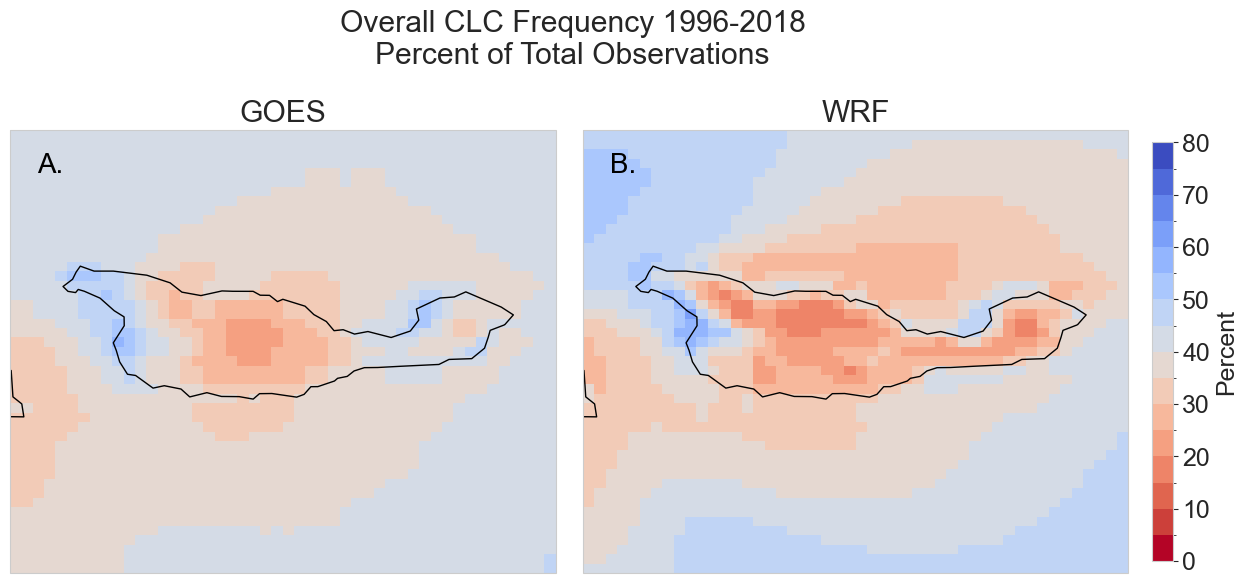

In [ ]:
## Plot Maps of CLC Frequency/Match
cmap = 'coolwarm_r'
# Year range for labels
min_year = int(clc_ds['time'].min().dt.year)
max_year = int(clc_ds['time'].max().dt.year)

# Group over all timesteps
clc_ds_gp = clc_ds.sum('time')
total_count = clc_ds.count('time')
clc_ds_gp = (clc_ds_gp / total_count) * 100

# Get match % statistic
perc_match = round(float(clc_ds_gp['match'].mean()),2)

# Plot data
fig, ax = plt.subplots(1, 2, figsize=(15,12), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.arange(0,85,5)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

## Plot GOES frequencies
var = 'goes_binary'
clc_ds_gp[var].plot(ax=ax[0], add_colorbar=False, norm=norm, cmap=cmap)

ax[0].text(0.05, 0.95, f'A.', transform=ax[0].transAxes,
                        fontsize=20, ha='left', va='top', color='black')
ax[0].coastlines()    

## Plot WRF frequencies
var = 'cldfra_binary'
clc_ds_gp[var].plot(ax=ax[1], add_colorbar=False, norm=norm, cmap=cmap)

ax[1].text(0.05, 0.95, f'B.', transform=ax[1].transAxes,
                        fontsize=20, ha='left', va='top', color='black')
ax[1].coastlines()

plt.subplots_adjust(wspace=0.05)  # Adjust space between plots

cbar = fig.colorbar(
    clc_ds_gp['cldfra_binary'].plot(add_colorbar=False, cmap=cmap, norm=norm),
    ax=ax,
    orientation='vertical',
    fraction=0.018, 
    pad=0.02, 
    #aspect=30, 
    label='Percent'
)

# Set Titles
fig.suptitle(f'Overall CLC Frequency {min_year}-{max_year}\nPercent of Total Observations',
             y=0.78)
ax[0].set(title=f'GOES')
ax[1].set(title=f'WRF')


plt.show()

In [ ]:
clc_ds_gp

<xarray.Dataset> Size: 91kB
Dimensions:        (lat: 47, lon: 48)
Coordinates:
  * lat            (lat) float32 188B 33.8 33.81 33.82 ... 34.18 34.19 34.2
  * lon            (lon) float32 192B -120.0 -120.0 -120.0 ... -119.5 -119.5
Data variables:
    cldfra         (lat, lon) float64 18kB 19.39 19.53 19.68 ... 19.84 19.88
    goes           (lat, lon) float64 18kB 1.543e+03 1.543e+03 ... 1.731e+03
    goes_binary    (lat, lon) float64 18kB 36.81 36.81 37.13 ... 42.52 42.63
    cldfra_binary  (lat, lon) float64 18kB 40.14 40.57 40.98 ... 40.9 41.01
    match          (lat, lon) float64 18kB 74.04 73.98 73.82 ... 64.84 64.92

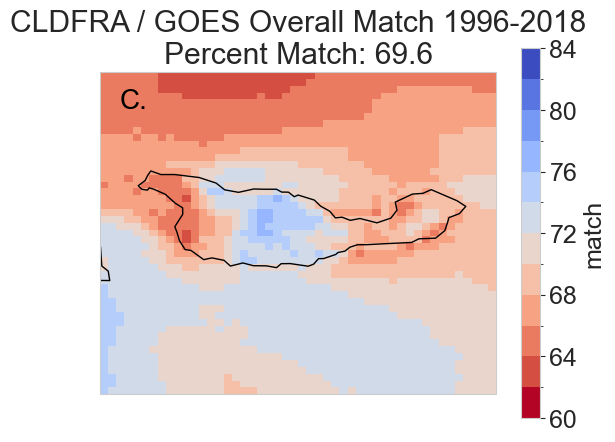

In [ ]:
## Plot match %
var = 'match'

fig, ax = plt.subplots(subplot_kw={'projection' : ccrs.PlateCarree()})
levels = np.arange(60,85,2)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

clc_ds_gp[var].plot(ax=ax, add_colorbar=True, norm=norm, cmap=cmap)
ax.set(title=f'CLDFRA / GOES Overall Match {min_year}-{max_year}\nPercent Match: {perc_match}')
ax.text(0.05, 0.95, f'C.', transform=ax.transAxes,
                        fontsize=20, ha='left', va='top', color='black')
ax.coastlines()
plt.show()

In [ ]:
## Alternate arrangement of monthly spatial plots
# Year range for labels
min_year = int(clc_ds['time'].min().dt.year)
max_year = int(clc_ds['time'].max().dt.year)

# Labels for each set of plots
var_dicts = [
    {'var' : 'match',
     'cbar_label' : '% Match',
     'title' : f'WRF/GOES Match % {min_year}-{max_year}'},

    {'var' : 'goes_binary',
     'cbar_label' : '% GOES',
     'title' : f'GOES CLC Frequency {min_year}-{max_year}'},

    {'var' : 'cldfra_binary',
     'cbar_label' : '% WRF',
     'title' : f'WRF CLC Frequency {min_year}-{max_year}'}
]

fig, ax = plt.subplots(5, 2, figsize=(8,15), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.arange(0,85,5)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

months = list(range(5, 10))
for i, month in enumerate(months):   
    clc_ds_month = clc_ds.sel(time=clc_ds['time'].dt.month == month)

    # Group over all timesteps
    clc_ds_gp = clc_ds_month.sum('time')
    total_count = clc_ds_month.count('time')
    clc_ds_gp = (clc_ds_gp / total_count) * 100

    # Get match % statistic
    perc_match = round(float(clc_ds_gp['match'].mean()), 2)

    # Plot data
    clc_ds_gp['goes_binary'].plot(ax=ax[i,0], add_colorbar=False, norm=norm, cmap=cmap)
    clc_ds_gp['cldfra_binary'].plot(ax=ax[i,1], add_colorbar=False, norm=norm, cmap=cmap)
    #clc_ds_gp['match'].plot(ax=ax[i,2], add_colorbar=False, norm=norm, cmap=cmap)  # -- Match
    
    for j in list(range(0,2)):
        ax[i,j].coastlines()

    #subplot_ax.text(0.05, 0.05, f'Month: {month}', transform=subplot_ax.transaAxes,
    #                fontsize=12, ha='left', va='bottom', color='black')
    

# Add titles
title_fontsize=14
ax[0,0].set_title('GOES CLC Frequency', fontsize=title_fontsize)
ax[0,1].set_title('WRF CLC Frequency', fontsize=title_fontsize)
#ax[0,2].set_title('Match Frequency', fontsize=title_fontsize)  # -- Match 

# Add month labels
for i, month in enumerate(['May', 'June', 'July', 'August', 'September']):
    ax[i, 0].text(-0.075, 0.5, f'{month}',
                    va='center', ha='center', rotation='vertical',
                    transform=ax[i, 0].transAxes, fontsize=16)

# Add overall title
plt.suptitle(f'{min_year}-{max_year}, Daylight Hours', y=0.935)
plt.subplots_adjust(wspace=-.15, hspace=0)

# Create a new axis for the colorbar
cbar_ax = fig.add_axes([0.9, 0.33, 0.02, 0.33])  # left, bottom, width, height

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

# Plot the colorbar
fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Percent')


plt.show()

NameError: name 'clc_ds' is not defined

## Interannual

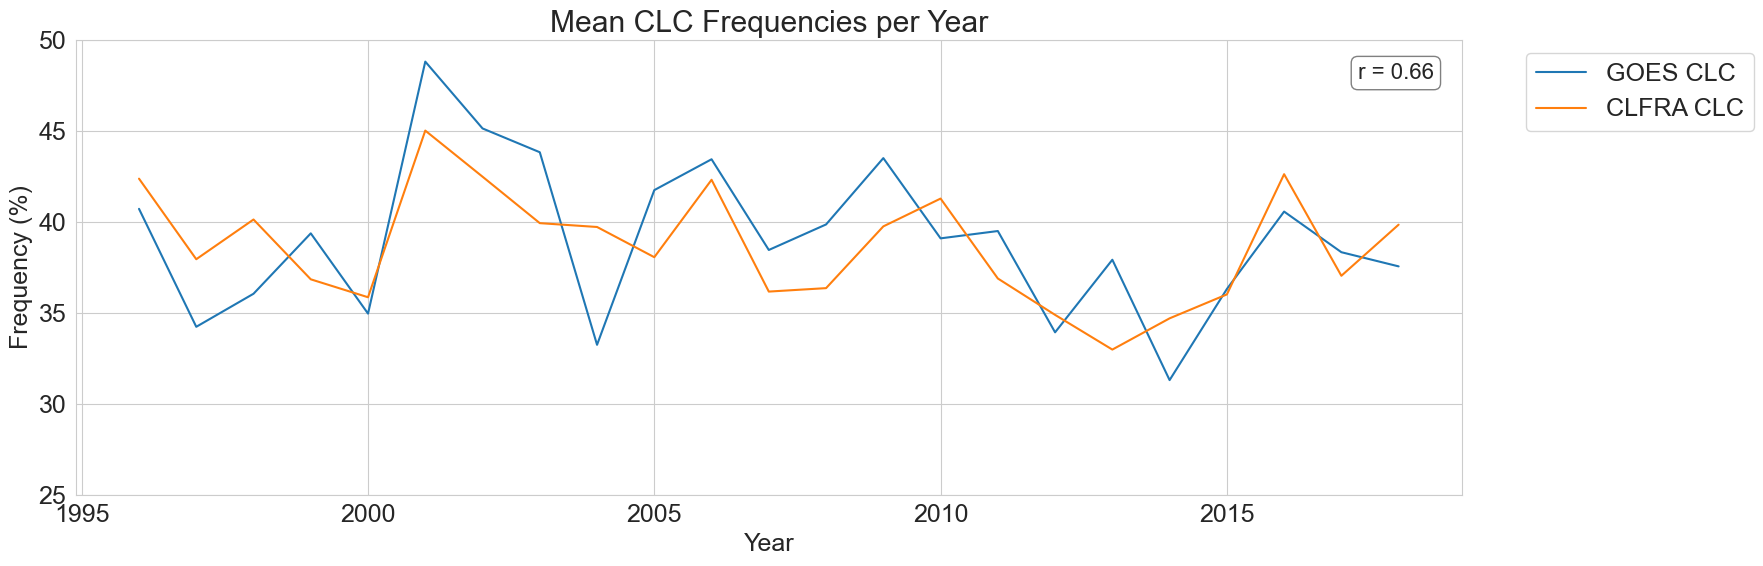

In [ ]:
### Interannual Comparisons
ds_gp = clc_ds.groupby('time.year').sum()
total_count = clc_ds.groupby('time.year').count()
ds_gp = ds_gp / total_count * 100
ds_gp = ds_gp.groupby('year').mean(dim=['lat', 'lon'])
df_gp = ds_gp[['goes_binary', 'cldfra_binary', 'match']].to_dataframe()
correlation = round(np.corrcoef(df_gp['goes_binary'], df_gp['cldfra_binary'])[0,1],2)

fig, ax = plt.subplots(figsize=(18,6))
sns.lineplot(data=df_gp,
             x='year',
             y='goes_binary',
             label='GOES CLC')
sns.lineplot(data=df_gp,
             x='year',
             y='cldfra_binary',
             label='CLFRA CLC')
#sns.lineplot(data=df_gp,
#            x='year',
#            y='match',
#            label='Match Frequency')
ax.set(title='Mean CLC Frequencies per Year',
       xlabel='Year',
       ylabel='Frequency (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1))
# Add annotation
ax.text(0.98, 0.95, f'r = {correlation:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=16, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
ax.set_ylim(25,50)


plt.tight_layout()

plt.show()


In [ ]:
round(np.corrcoef(df_gp['goes_binary'], df_gp['cldfra_binary'])[0,1],2)

np.float64(0.66)

## Interannual - Clipped to Coast
Clip the dataset to only cells intersecting the coastline, and rerun the interannual trend plot. 

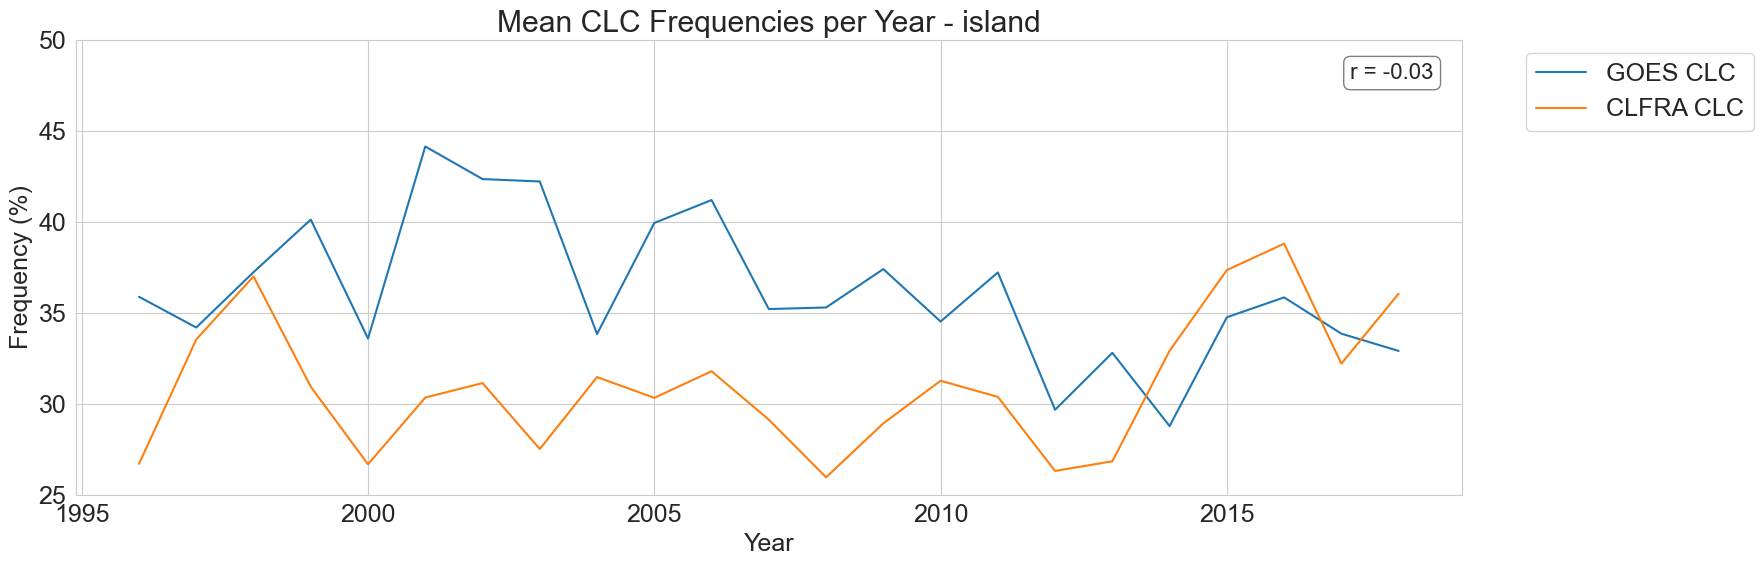

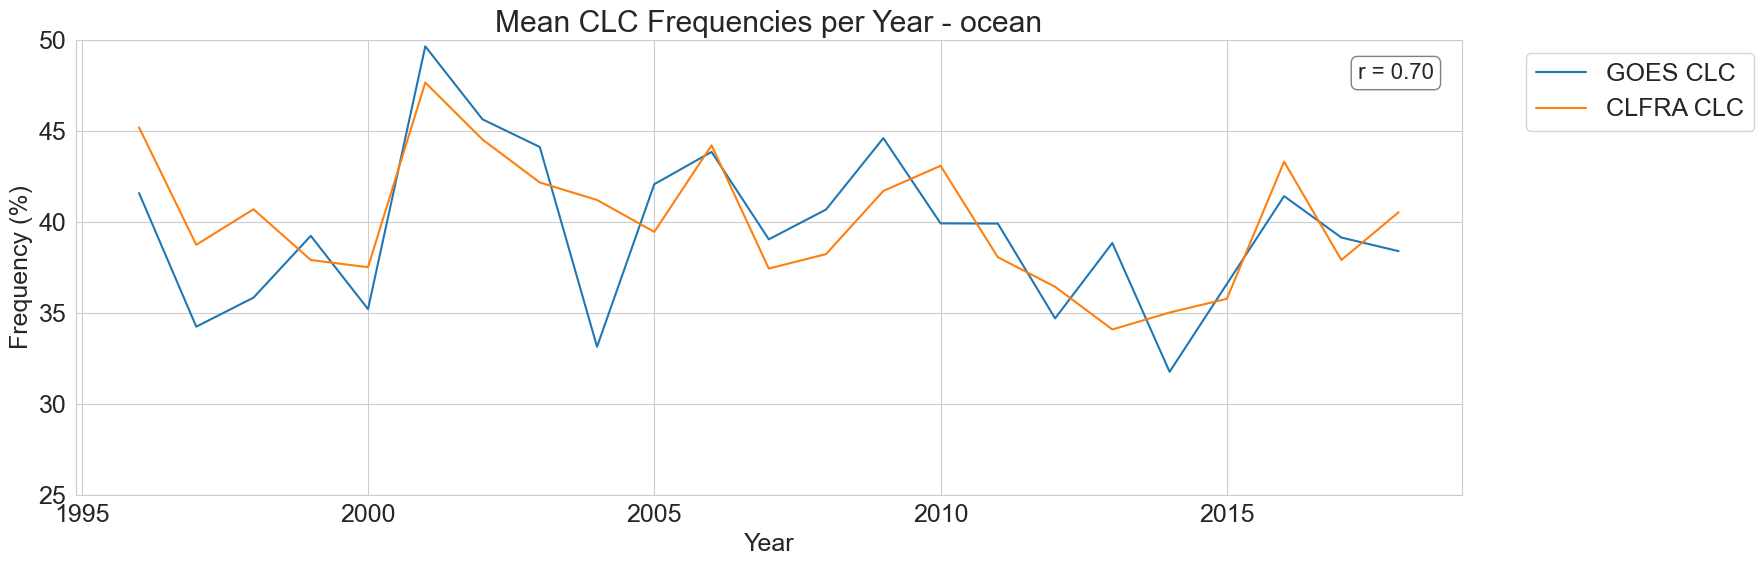

In [ ]:
island_masked = clc_ds.salem.roi(shape=sci_coast, all_touched=True)  # Clip to pixels intersecting the island

ocean_mask = island_masked.sel(time='2014-08-30T12:00:00.000000000')['goes_binary']  # Use this as mask
ocean_masked = clc_ds.where(np.isnan(ocean_mask))  # invert the island mask

dict_list = [
    {'mask' : island_masked,
     'all_touched' : True,
     'type' : 'island'},
     
    {'mask' : ocean_masked,
     'all_touched' : False,
     'type' : 'ocean'}
]

for masked in dict_list:
        ds_gp = masked['mask'].groupby('time.year').sum()
        total_count = masked['mask'].groupby('time.year').count()
        ds_gp = ds_gp / total_count * 100
        ds_gp = ds_gp.groupby('year').mean(dim=['lat', 'lon'])
        df_gp = ds_gp[['goes_binary', 'cldfra_binary', 'match']].to_dataframe()
        correlation = round(np.corrcoef(df_gp['goes_binary'], df_gp['cldfra_binary'])[0,1],2)

        fig, ax = plt.subplots(figsize=(18,6))
        sns.lineplot(data=df_gp,
                x='year',
                y='goes_binary',
                label='GOES CLC')
        sns.lineplot(data=df_gp,
                x='year',
                y='cldfra_binary',
                label='CLFRA CLC')
        #sns.lineplot(data=df_gp,
        #            x='year',
        #            y='match',
        #            label='Match Frequency')
        ax.set(title=f'Mean CLC Frequencies per Year - {masked['type']}',
        xlabel='Year',
        ylabel='Frequency (%)')
        plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1))
        # Add annotation
        ax.text(0.98, 0.95, f'r = {correlation:.2f}',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=16, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
        ax.set_ylim(25, 50)


        plt.tight_layout()

        plt.show()


## Monthly Analysis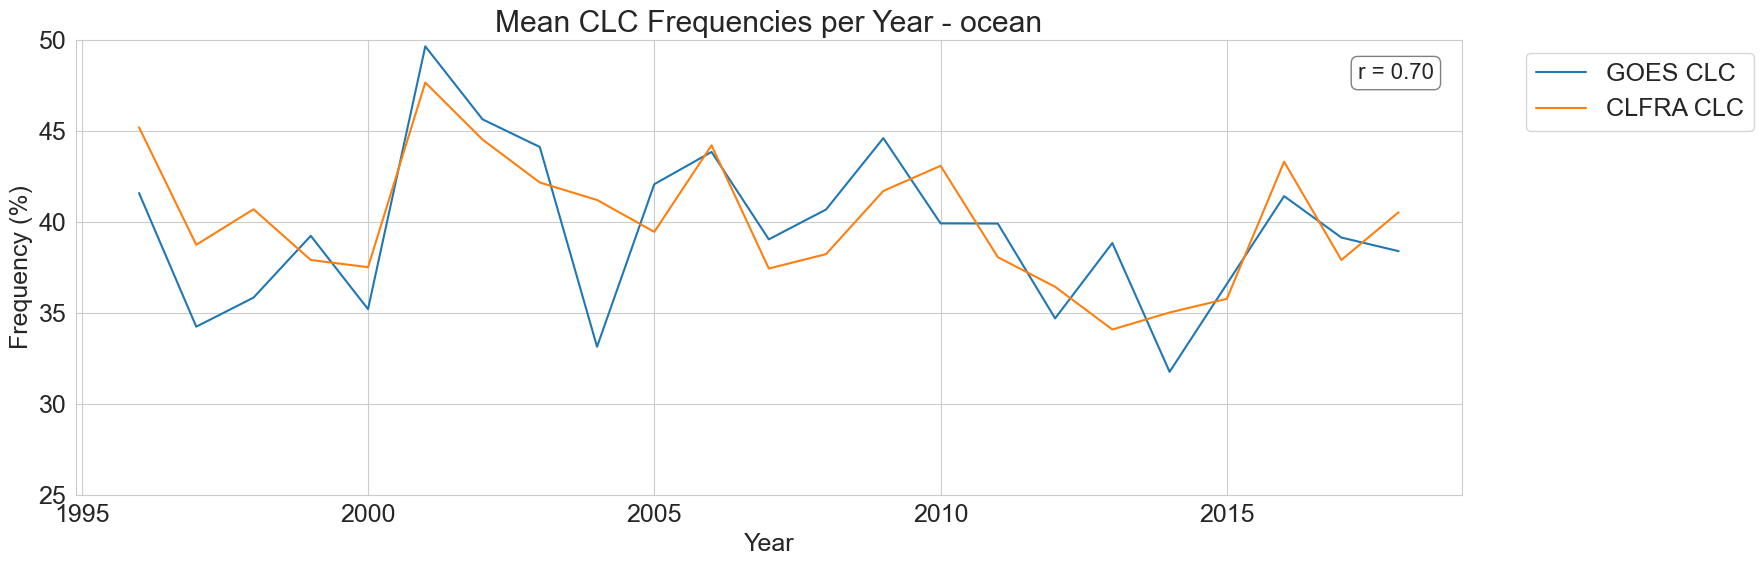

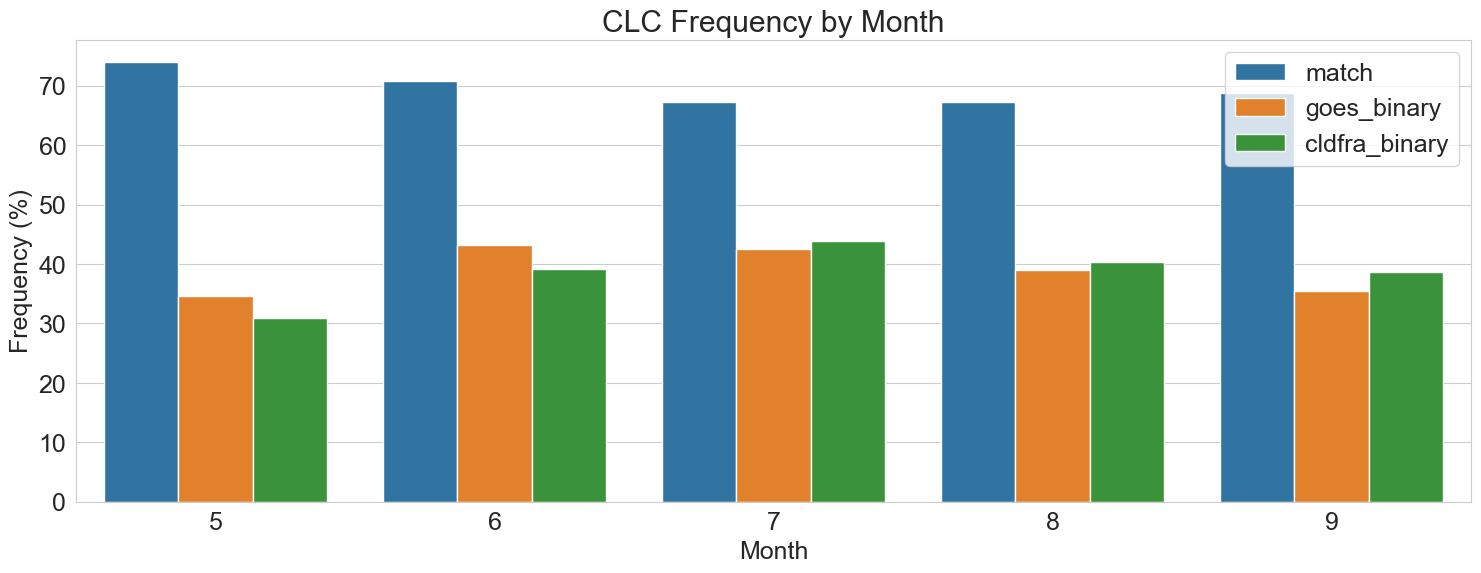

In [ ]:
# Monthly analysis bar chart

# Bar plot of % match per month
min_year = int(clc_ds['time'].min().dt.year)
max_year = int(clc_ds['time'].max().dt.year)

months_ds = clc_ds.groupby('time.month').sum('time')
months_count = clc_ds.groupby('time.month').count('time')
months_ds = (months_ds / months_count) * 100

match_da = months_ds[['match', 'goes_binary', 'cldfra_binary']]
match_da = match_da.groupby('month').mean(dim=['lat', 'lon'])
match_df = match_da.to_dataframe().reset_index()
match_df_long = match_df.melt(id_vars='month', var_name='type', value_name='frequency')

fig, ax = plt.subplots(figsize=(18, 6))
sns.barplot(data=match_df_long,
            x='month',
            y='frequency',
            hue='type')
ax.set(title='CLC Frequency by Month',
       xlabel='Month',
       ylabel='Frequency (%)')
plt.legend(title='')
plt.show()

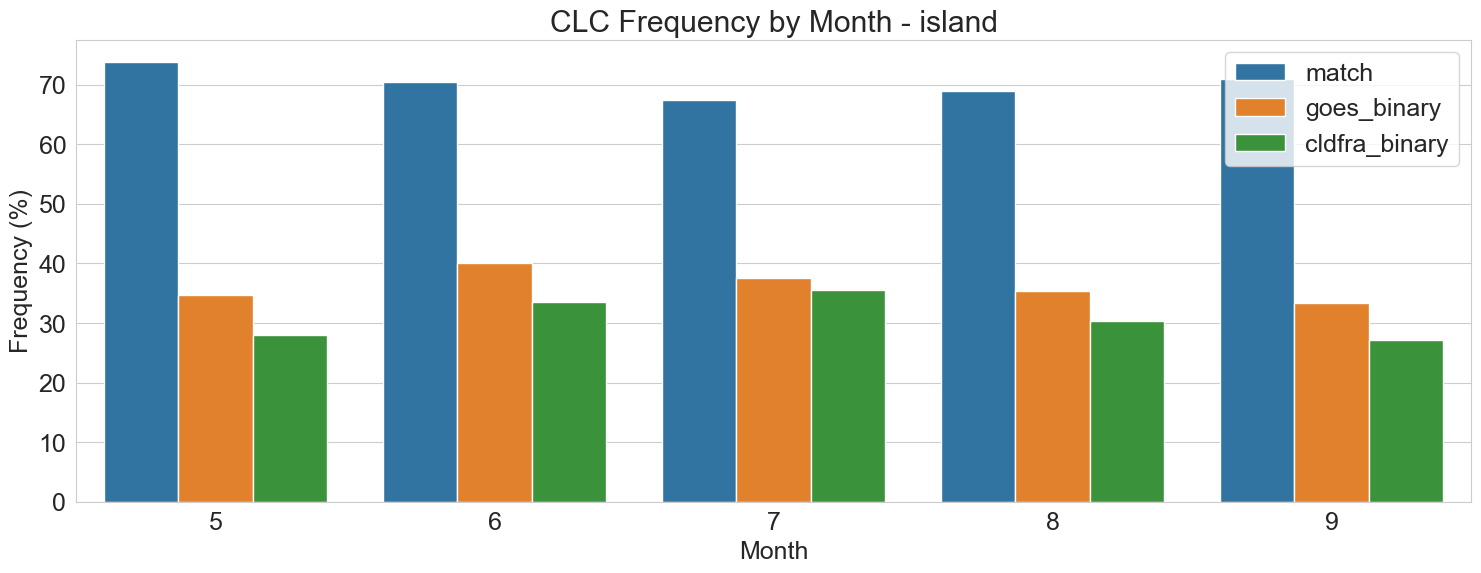

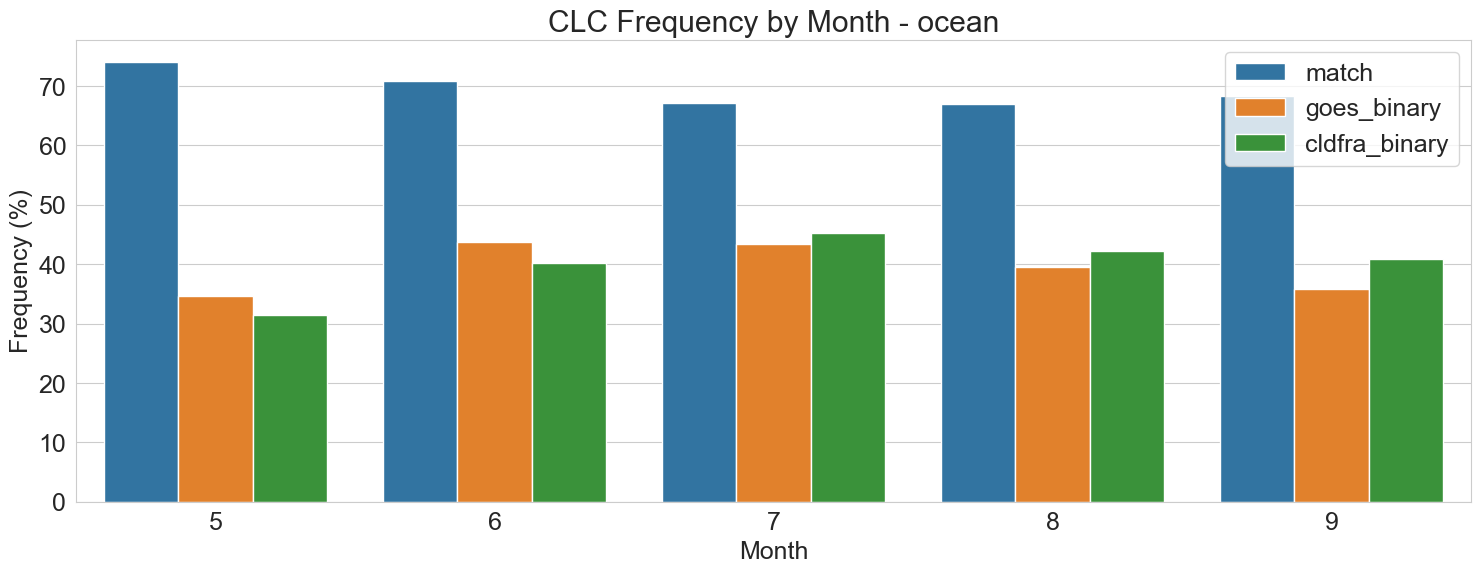

In [ ]:
# Monthly analysis bar chart

# Bar plot of % match per month

for masked in dict_list:
       min_year = int(masked['mask']['time'].min().dt.year)
       max_year = int(masked['mask']['time'].max().dt.year)

       months_ds = masked['mask'].groupby('time.month').sum('time')
       months_count = masked['mask'].groupby('time.month').count('time')
       months_ds = (months_ds / months_count) * 100

       match_da = months_ds[['match', 'goes_binary', 'cldfra_binary']]
       match_da = match_da.groupby('month').mean(dim=['lat', 'lon'])
       match_df = match_da.to_dataframe().reset_index()
       match_df_long = match_df.melt(id_vars='month', var_name='type', value_name='frequency')

       fig, ax = plt.subplots(figsize=(18, 6))
       sns.barplot(data=match_df_long,
              x='month',
              y='frequency',
              hue='type')
       ax.set(title=f'CLC Frequency by Month - {masked['type']}',
              xlabel='Month',
              ylabel='Frequency (%)')
       plt.legend(title='')
       plt.show()

# ROI Analysis

In [ ]:
# Create Regions of Interest

# Define centers of regions of interest
site_dict = {
    'site' : ['west-end', 'coche-point', 'inland', 'nw-ocean', 'se-ocean'],
    'lat' : [34.012499, 34.033456, 34.00346, 34.12030, 33.91093],
    'lon' : [-119.882897, -119.600946, -119.76288, -119.95199, -119.60004]
}

site_df = pd.DataFrame(site_dict)

# Get regions of interest using centers
bounds_df = pd.DataFrame()
for i, site in site_df.iterrows():
    bounds_df = pd.concat([bounds_df, get_bounds(clc_ds, site)])

site_df = site_df.merge(bounds_df, on='site')
site_df

,site,lat,lon,lat_min,lat_max,lon_min,lon_max,bounds
0,west-end,34.012499,-119.882897,33.996542,34.022379,-119.898397,-119.867236,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
1,coche-point,34.033456,-119.600946,34.022375,34.048197,-119.617971,-119.586810,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
2,inland,34.003460,-119.762880,33.987936,34.013773,-119.773763,-119.742602,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
3,nw-ocean,34.120300,-119.951990,34.108411,34.134219,-119.971097,-119.939936,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...
4,se-ocean,33.910930,-119.600040,33.901785,33.927630,-119.617971,-119.586810,[(<xarray.DataArray 'lon' ()> Size: 8B\narray(...


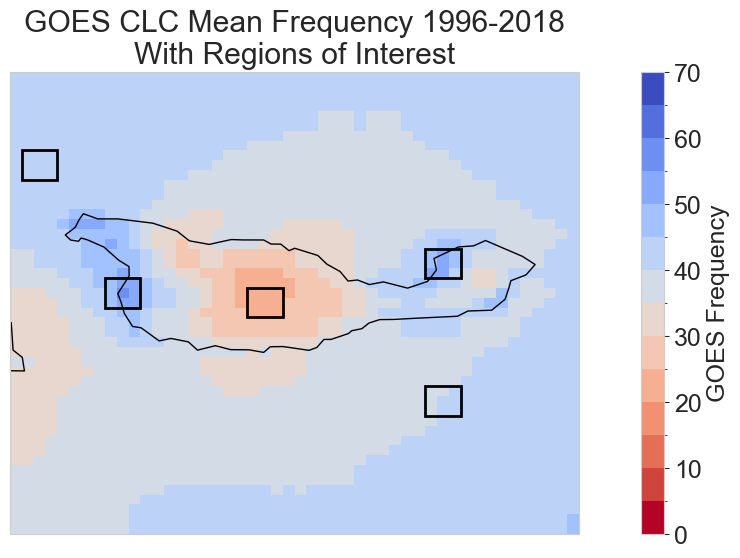

In [ ]:
# Plot regions of interest
min_year = int(clc_ds['time'].min().dt.year)
max_year = int(clc_ds['time'].max().dt.year)

# Group over entire dataset
ds_gp = clc_ds.sum('time')
total_count = clc_ds.count('time')
ds_gp = (ds_gp / total_count) * 100
goes_da = ds_gp['goes_binary']

# Plot regions of interest over GOES frequencies
fig, ax = plt.subplots(figsize=(16,6), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.arange(0,75,5)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
goes_da.plot(ax=ax, cbar_kwargs={"shrink": 1, "label": "GOES Frequency"}, cmap=cmap, norm=norm)
for i, site in site_df.iterrows():
    polygon = Polygon(site['bounds'], closed=True, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(polygon)
ax.set(title=f'GOES CLC Mean Frequency {min_year}-{max_year}\nWith Regions of Interest')
ax.coastlines()
plt.show()

# ROI Analysis

## Bar Plots

### Full dataset frequencies

In [ ]:
site_order = ['overall', 'nw-ocean', 'west-end', 'inland', 'coche-point', 'se-ocean']  # Ordered W->E

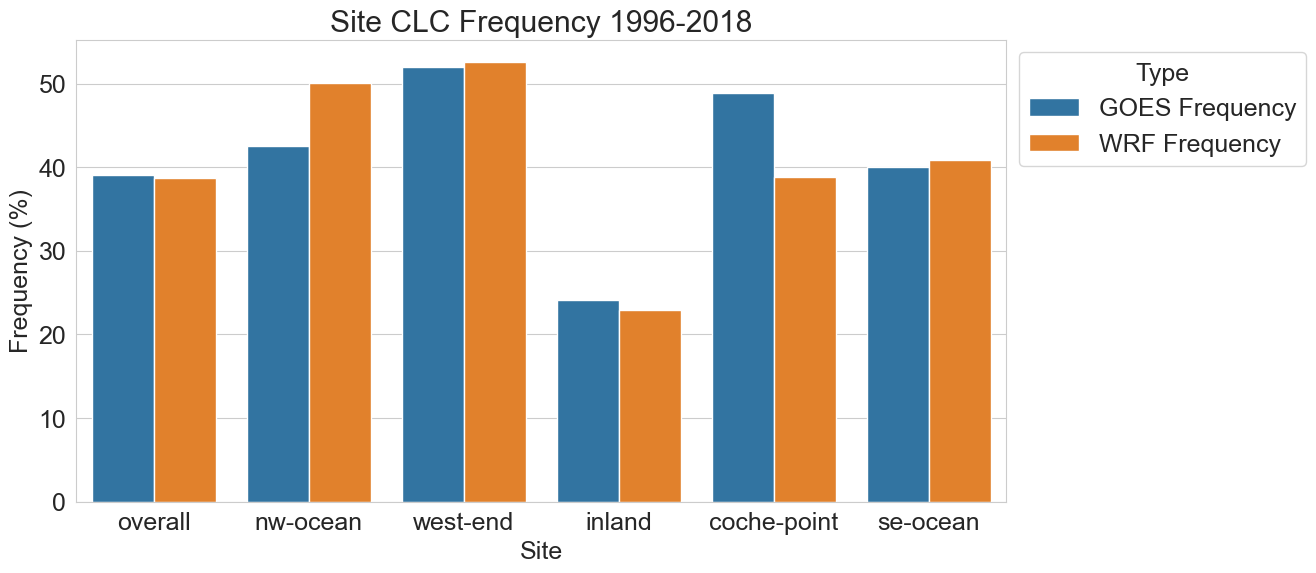

In [ ]:
# Plot regions of interest
min_year = int(clc_ds['time'].min().dt.year)
max_year = int(clc_ds['time'].max().dt.year)

# Get frequencies
freq_df = get_freq(clc_ds, 'cldfra_binary', site_df)
freq_df = freq_df.drop('match_freq', axis=1)

# Cast to long
freq_df_long = freq_df.melt(id_vars='site', var_name='type', value_name='frequency')

# Plot frequencies by ROI
## Create barplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=freq_df_long,
            x='site',
            y='frequency',
            hue='type',
            #hue_order=['match_freq', 'goes_freq', 'wrf_freq'],
            hue_order=['goes_freq', 'wrf_freq'],
            order=site_order,
            ax=ax)
ax.set(title=f'Site CLC Frequency {min_year}-{max_year}',
       xlabel='Site',
       ylabel='Frequency (%)')

## Specify legend
handles, labels = ax.get_legend_handles_labels()
#custom_labels = ["GOES / WRF Match", "GOES Frequency", "WRF Frequency"]
custom_labels = ['GOES Frequency', 'WRF Frequency']
ax.legend(handles, custom_labels, title="Type", loc='upper left', 
          bbox_to_anchor=(1, 1))

plt.show()


### ROI Frequencies by Month

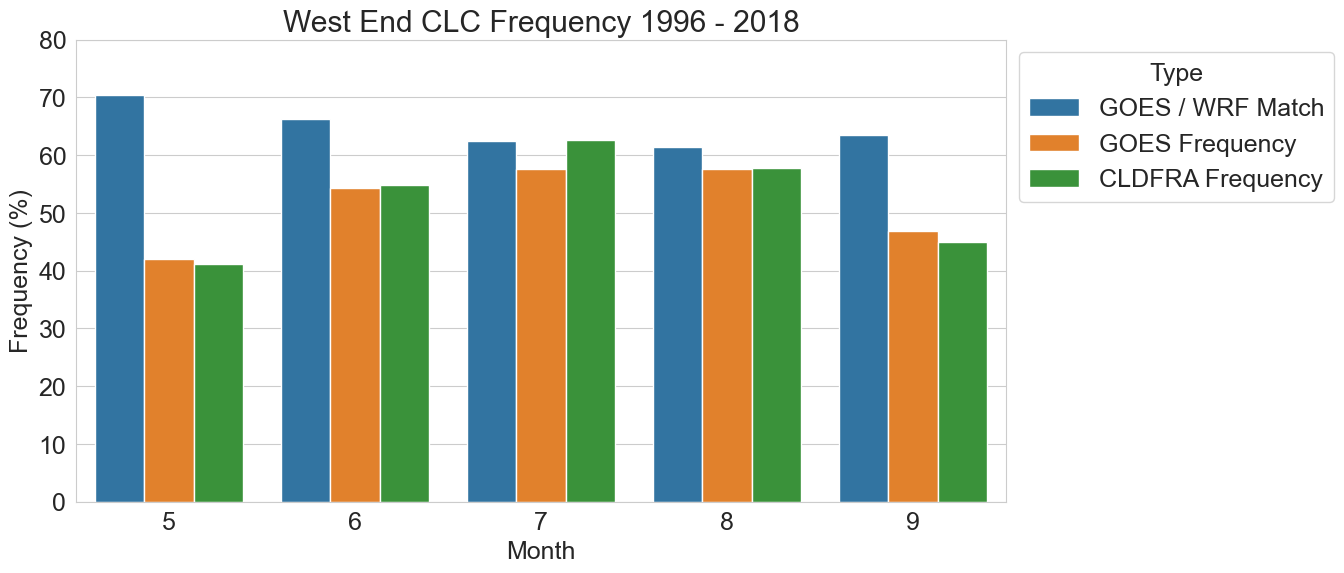

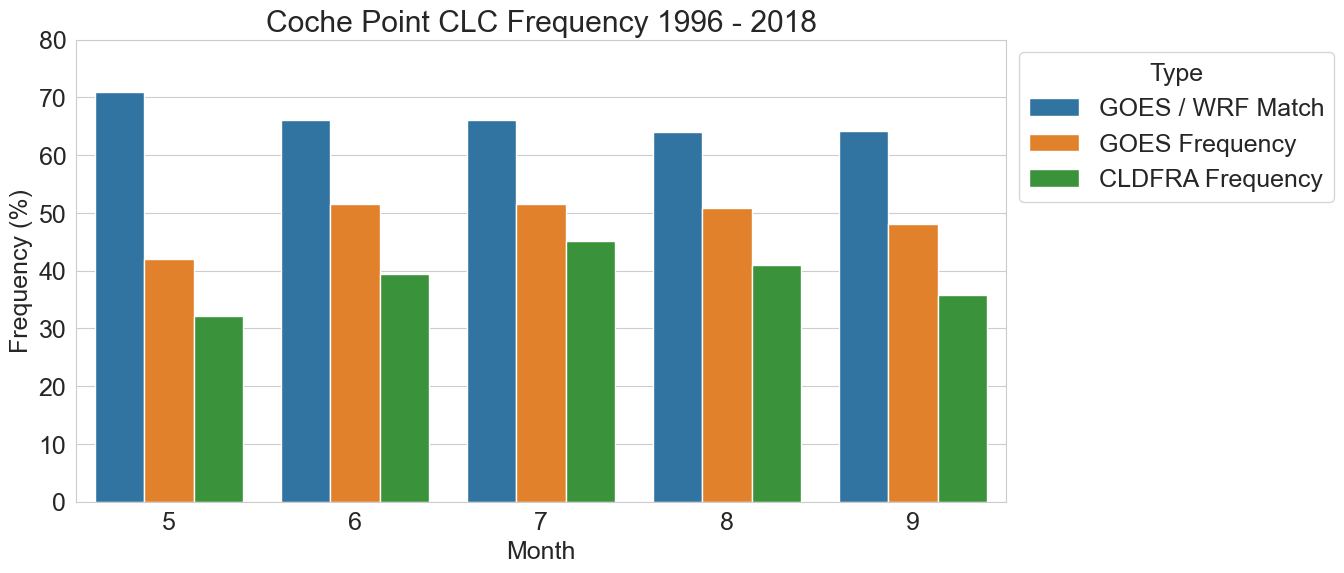

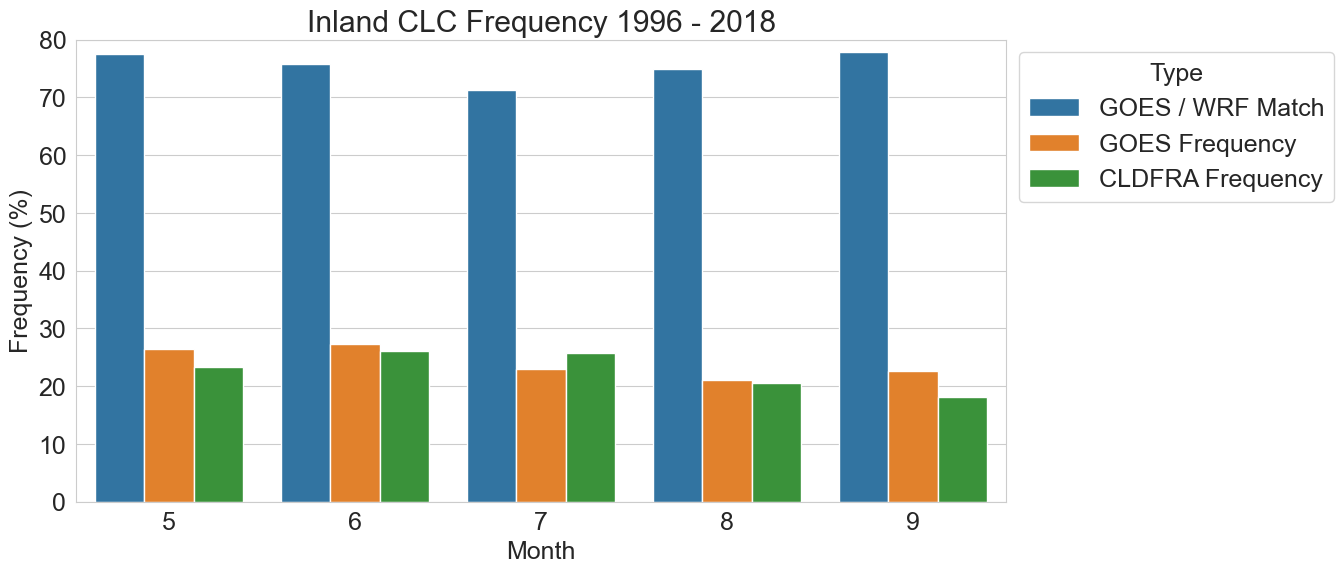

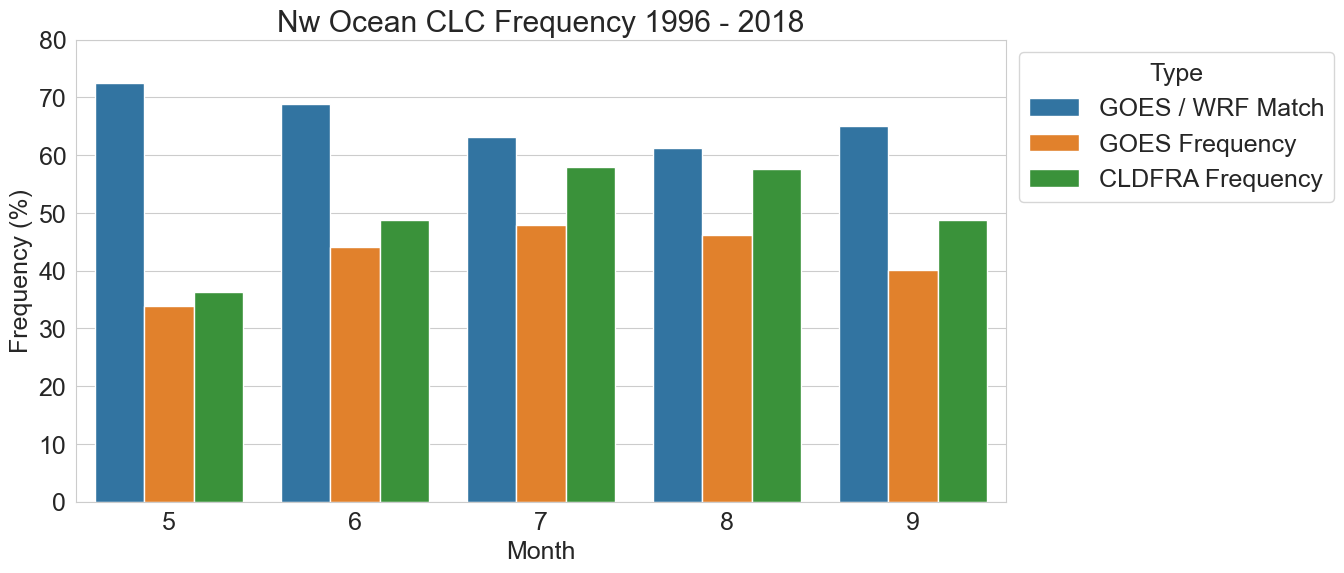

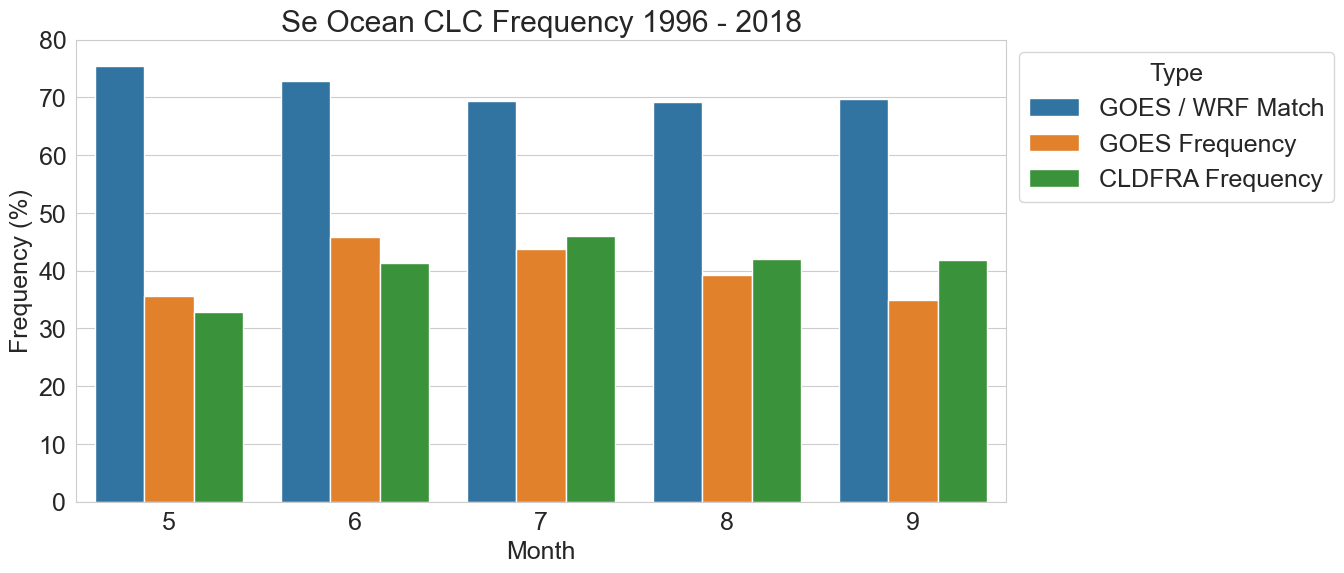

In [ ]:
# Get monthly frequencies
freq_df = get_monthly_freq(clc_ds, site_df)

# Plot ROI mean frequencies by month
for site in freq_df['site'].unique().tolist():
    site_freq_df = freq_df.loc[freq_df['site'] == site].drop('site', axis=1)
    site_freq_df_long = site_freq_df.melt(id_vars='month', var_name='type', value_name='frequency')

    norm1 = mcolors.Normalize(vmin=0, vmax=80)  # Normalize color bar range

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=site_freq_df_long,
                x='month',
                y='frequency',
                hue='type',
                hue_order=['match_freq', 'goes_freq', 'cldfra_freq'],
                ax=ax)
    ax.set_ylim(0,80)


    # Customize legend labels
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ["GOES / WRF Match", "GOES Frequency", "CLDFRA Frequency"]
    ax.legend(handles, custom_labels, title="Type", loc='upper left', 
            bbox_to_anchor=(1, 1))

    site = site.replace("-", " ").title()
    ax.set(title=f'{site} CLC Frequency {min_year} - {max_year}',
        xlabel='Month',
        ylabel='Frequency (%)')

    plt.show()

### Interannual Statistics

In [ ]:
# Get yearly frequencies
freq_df = get_yearly_freq(clc_ds, site_df)
freq_df

,site,year,goes_freq,cldfra_freq,match_freq
0,west-end,1996,56.072351,50.166113,67.811000
0,west-end,1997,42.224535,50.150306,66.579951
0,west-end,1998,48.796830,55.287537,61.393696
0,west-end,1999,54.602012,56.375371,61.829176
0,west-end,2000,47.880155,46.781190,65.330557
...,...,...,...,...,...
0,se-ocean,2014,31.417840,35.211268,72.707355
0,se-ocean,2015,37.837169,35.678050,64.606533
0,se-ocean,2016,41.637297,45.068942,70.574414
0,se-ocean,2017,40.856224,36.519426,70.892106


In [ ]:
stats_df = pd.DataFrame()

# Overall statistics
corr = np.corrcoef(df_gp['goes_binary'], df_gp['cldfra_binary'])[0, 1]

bias = np.mean((df_gp['cldfra_binary'] - df_gp['goes_binary']))
rmse = np.sqrt(np.mean((df_gp['cldfra_binary'] - df_gp['goes_binary'])**2))

stat_dict = {
    'site' : 'Overall',
    'correlation' : round(corr, 2),
    'bias' : round(bias, 2),
    'rmse' : round(rmse, 2)
    }
site_stats = pd.DataFrame([stat_dict])
stats_df = pd.concat([stats_df, site_stats], axis=0)

# AOI Statistics
for site in freq_df['site'].unique():
    site_stats_df = freq_df.loc[freq_df['site'] == site]
    corr = np.corrcoef(site_stats_df['goes_freq'], site_stats_df['cldfra_freq'])[0, 1]
    
    bias = np.mean((site_stats_df['cldfra_freq'] - site_stats_df['goes_freq']))
    rmse = np.sqrt(np.mean((site_stats_df['cldfra_freq'] - site_stats_df['goes_freq'])**2))

    stat_dict = {
        'site' : site,
        'correlation' : round(corr, 2),
        'bias' : round(bias, 2),
        'rmse' : round(rmse, 2)
        }
    site_stats = pd.DataFrame([stat_dict])
    stats_df = pd.concat([stats_df, site_stats], axis=0)



stats_df.T

,0,0,0,0,0,0
site,Overall,west-end,coche-point,inland,nw-ocean,se-ocean
correlation,0.7,0.13,-0.1,0.1,0.69,0.5
bias,0.49,0.69,-9.92,-1.18,7.56,0.88
rmse,3.11,5.74,12.23,5.53,8.35,4.57


### ROI Frequencies by Year


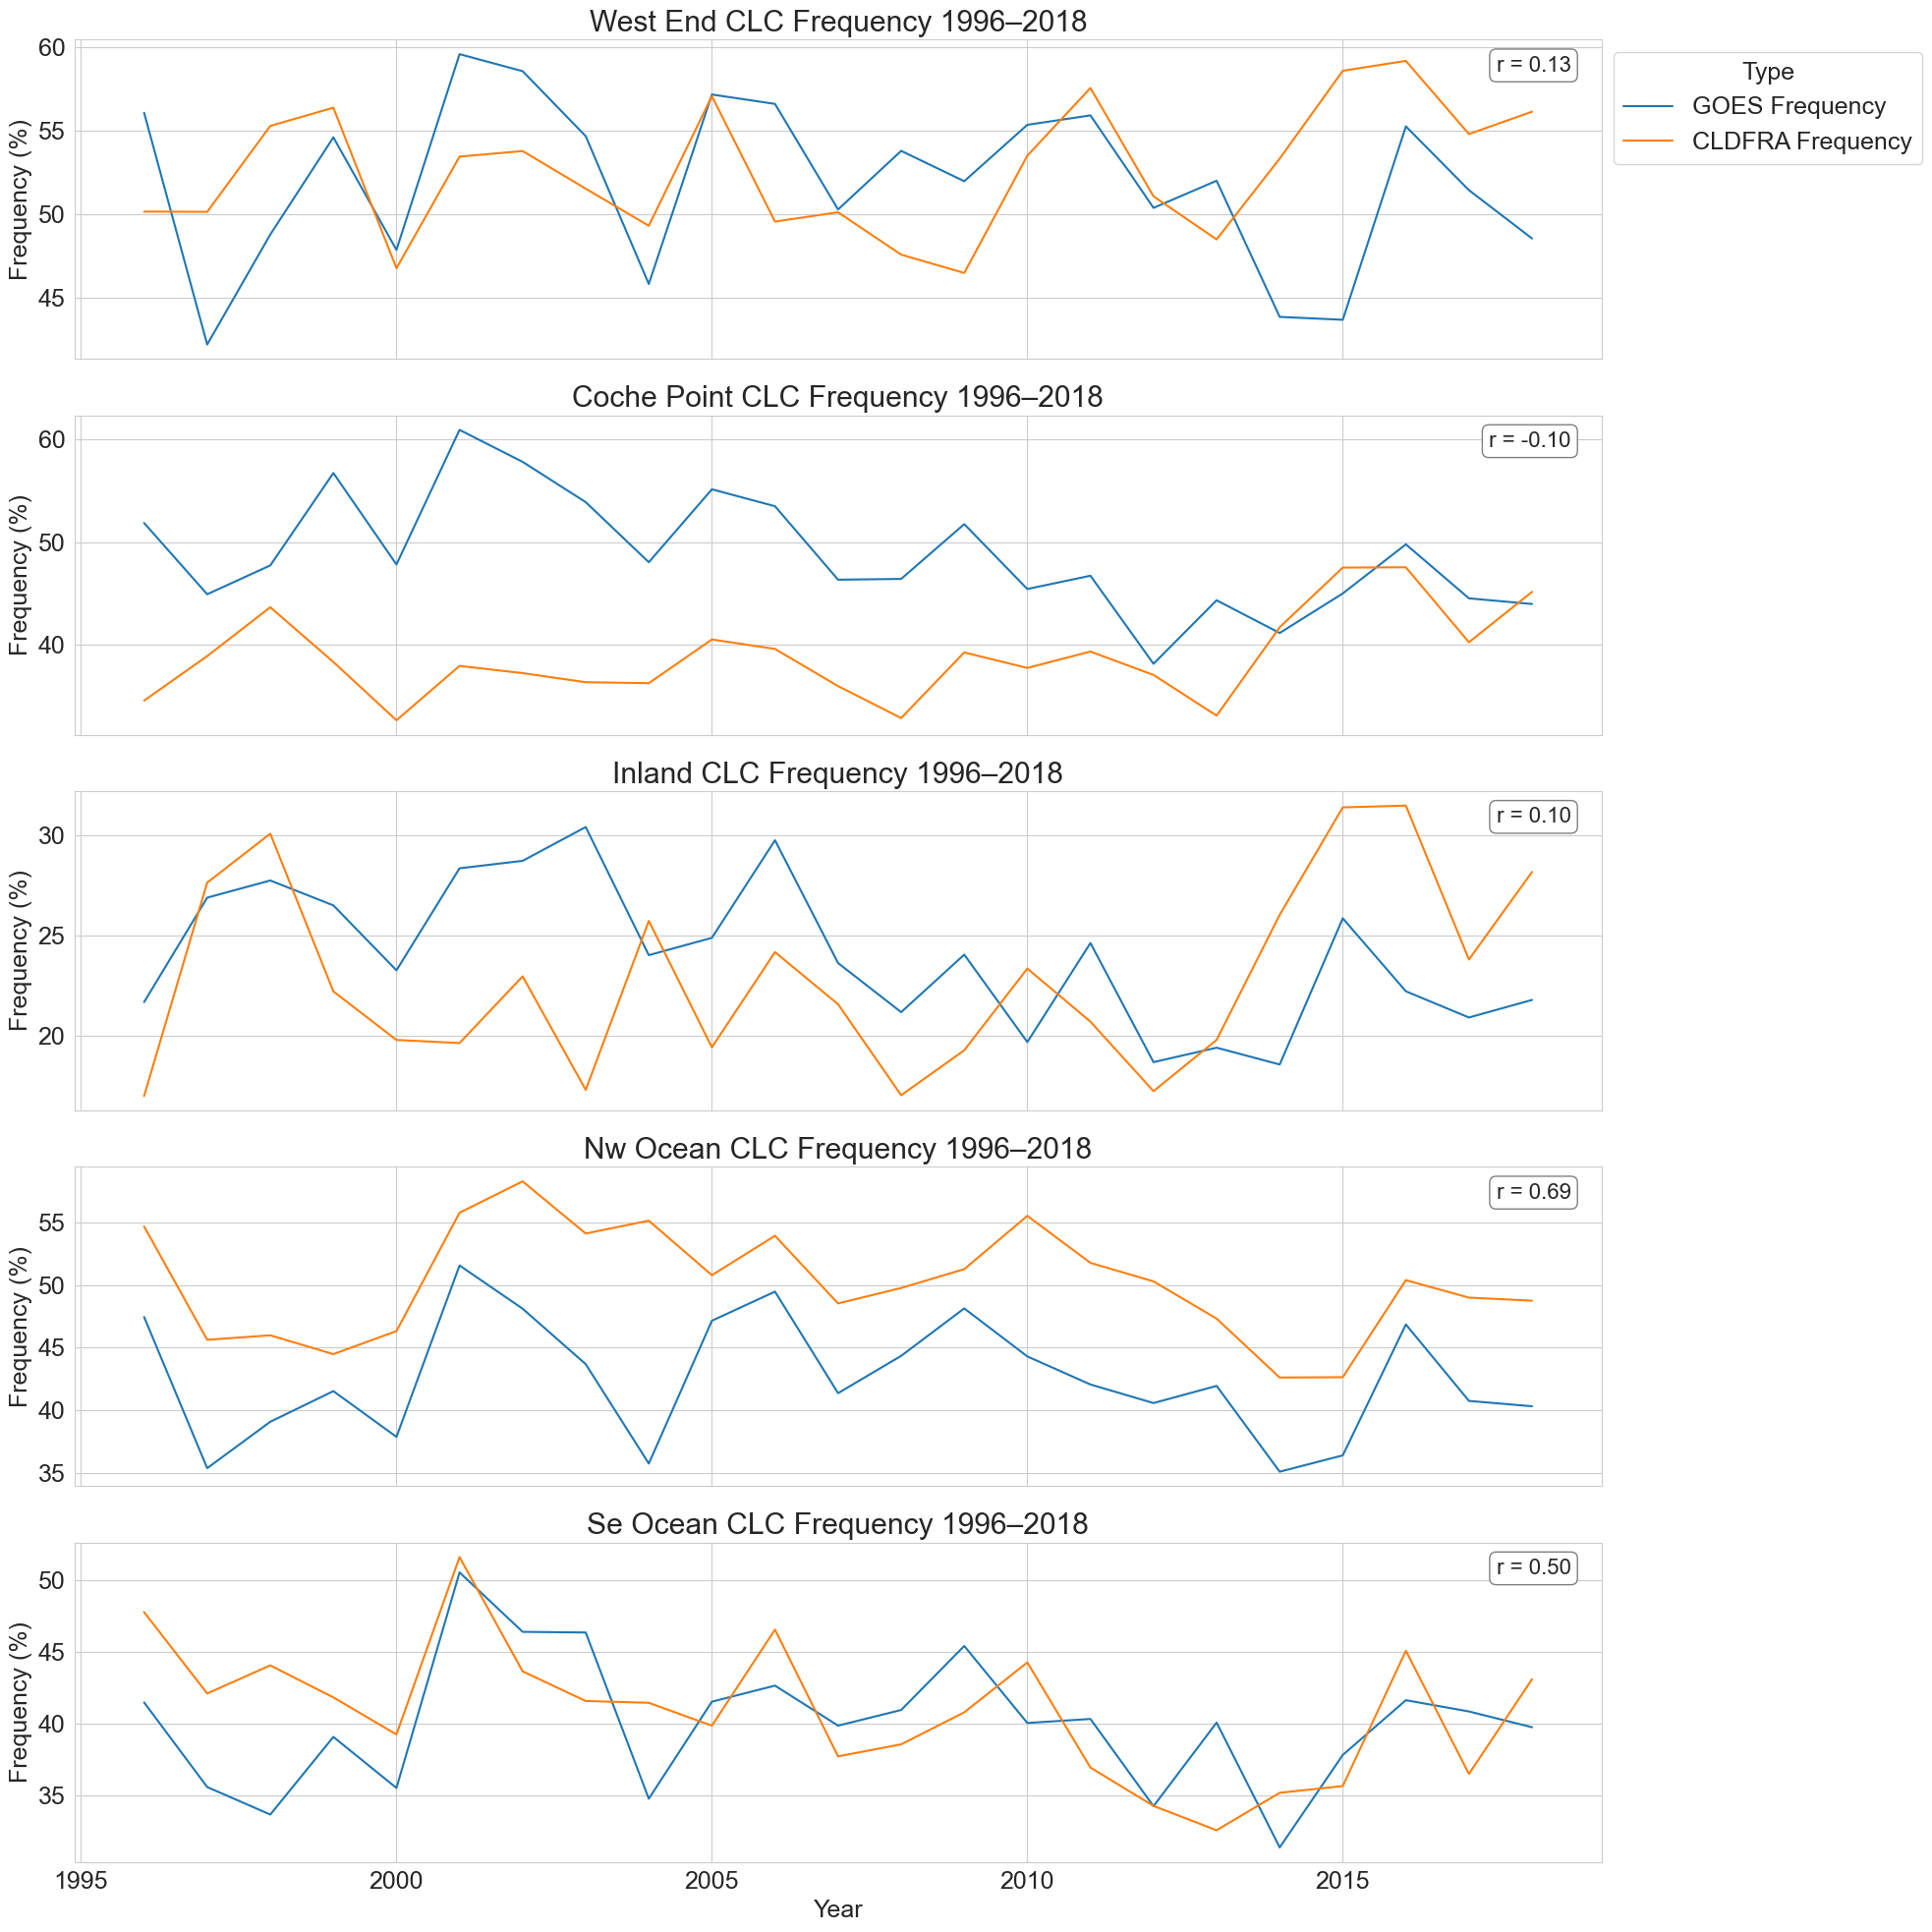

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get yearly frequencies
freq_df = get_yearly_freq(clc_ds, site_df)

# Get unique sites
sites = freq_df['site'].unique().tolist()
n_sites = len(sites)

# Set up subplots: one row per site, shared x-axis
fig, axes = plt.subplots(nrows=n_sites, ncols=1, figsize=(20, 4 * n_sites), sharex=True)

# Ensure axes is always iterable
if n_sites == 1:
    axes = [axes]

# Loop through sites
for i, site in enumerate(sites):
    site_freq_df = freq_df.loc[freq_df['site'] == site].drop('site', axis=1)
    site_freq_df_long = site_freq_df.melt(id_vars='year', var_name='type', value_name='frequency')

    ax = axes[i]
    sns.lineplot(
        data=site_freq_df_long.loc[site_freq_df_long['type'] != 'match_freq'],
        x='year',
        y='frequency',
        hue='type',
        hue_order=['goes_freq', 'cldfra_freq'],
        ax=ax
    )

    # Customize legend for first subplot only
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        custom_labels = ["GOES Frequency", "CLDFRA Frequency"]
        ax.legend(handles, custom_labels, title="Type", loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.legend().remove()

    # Title and y-label
    formatted_site = site.replace("-", " ").title()
    ax.set(
        title=f'{formatted_site} CLC Frequency {site_freq_df["year"].min()}–{site_freq_df["year"].max()}',
        ylabel='Frequency (%)'
    )

    # Compute and annotate correlation
    correlation = np.corrcoef(site_freq_df['goes_freq'], site_freq_df['cldfra_freq'])[0, 1]
    ax.text(
        0.98, 0.95, f'r = {correlation:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray')
    )

# Common x-axis label
axes[-1].set_xlabel('Year')

# Layout
plt.tight_layout()
plt.show()


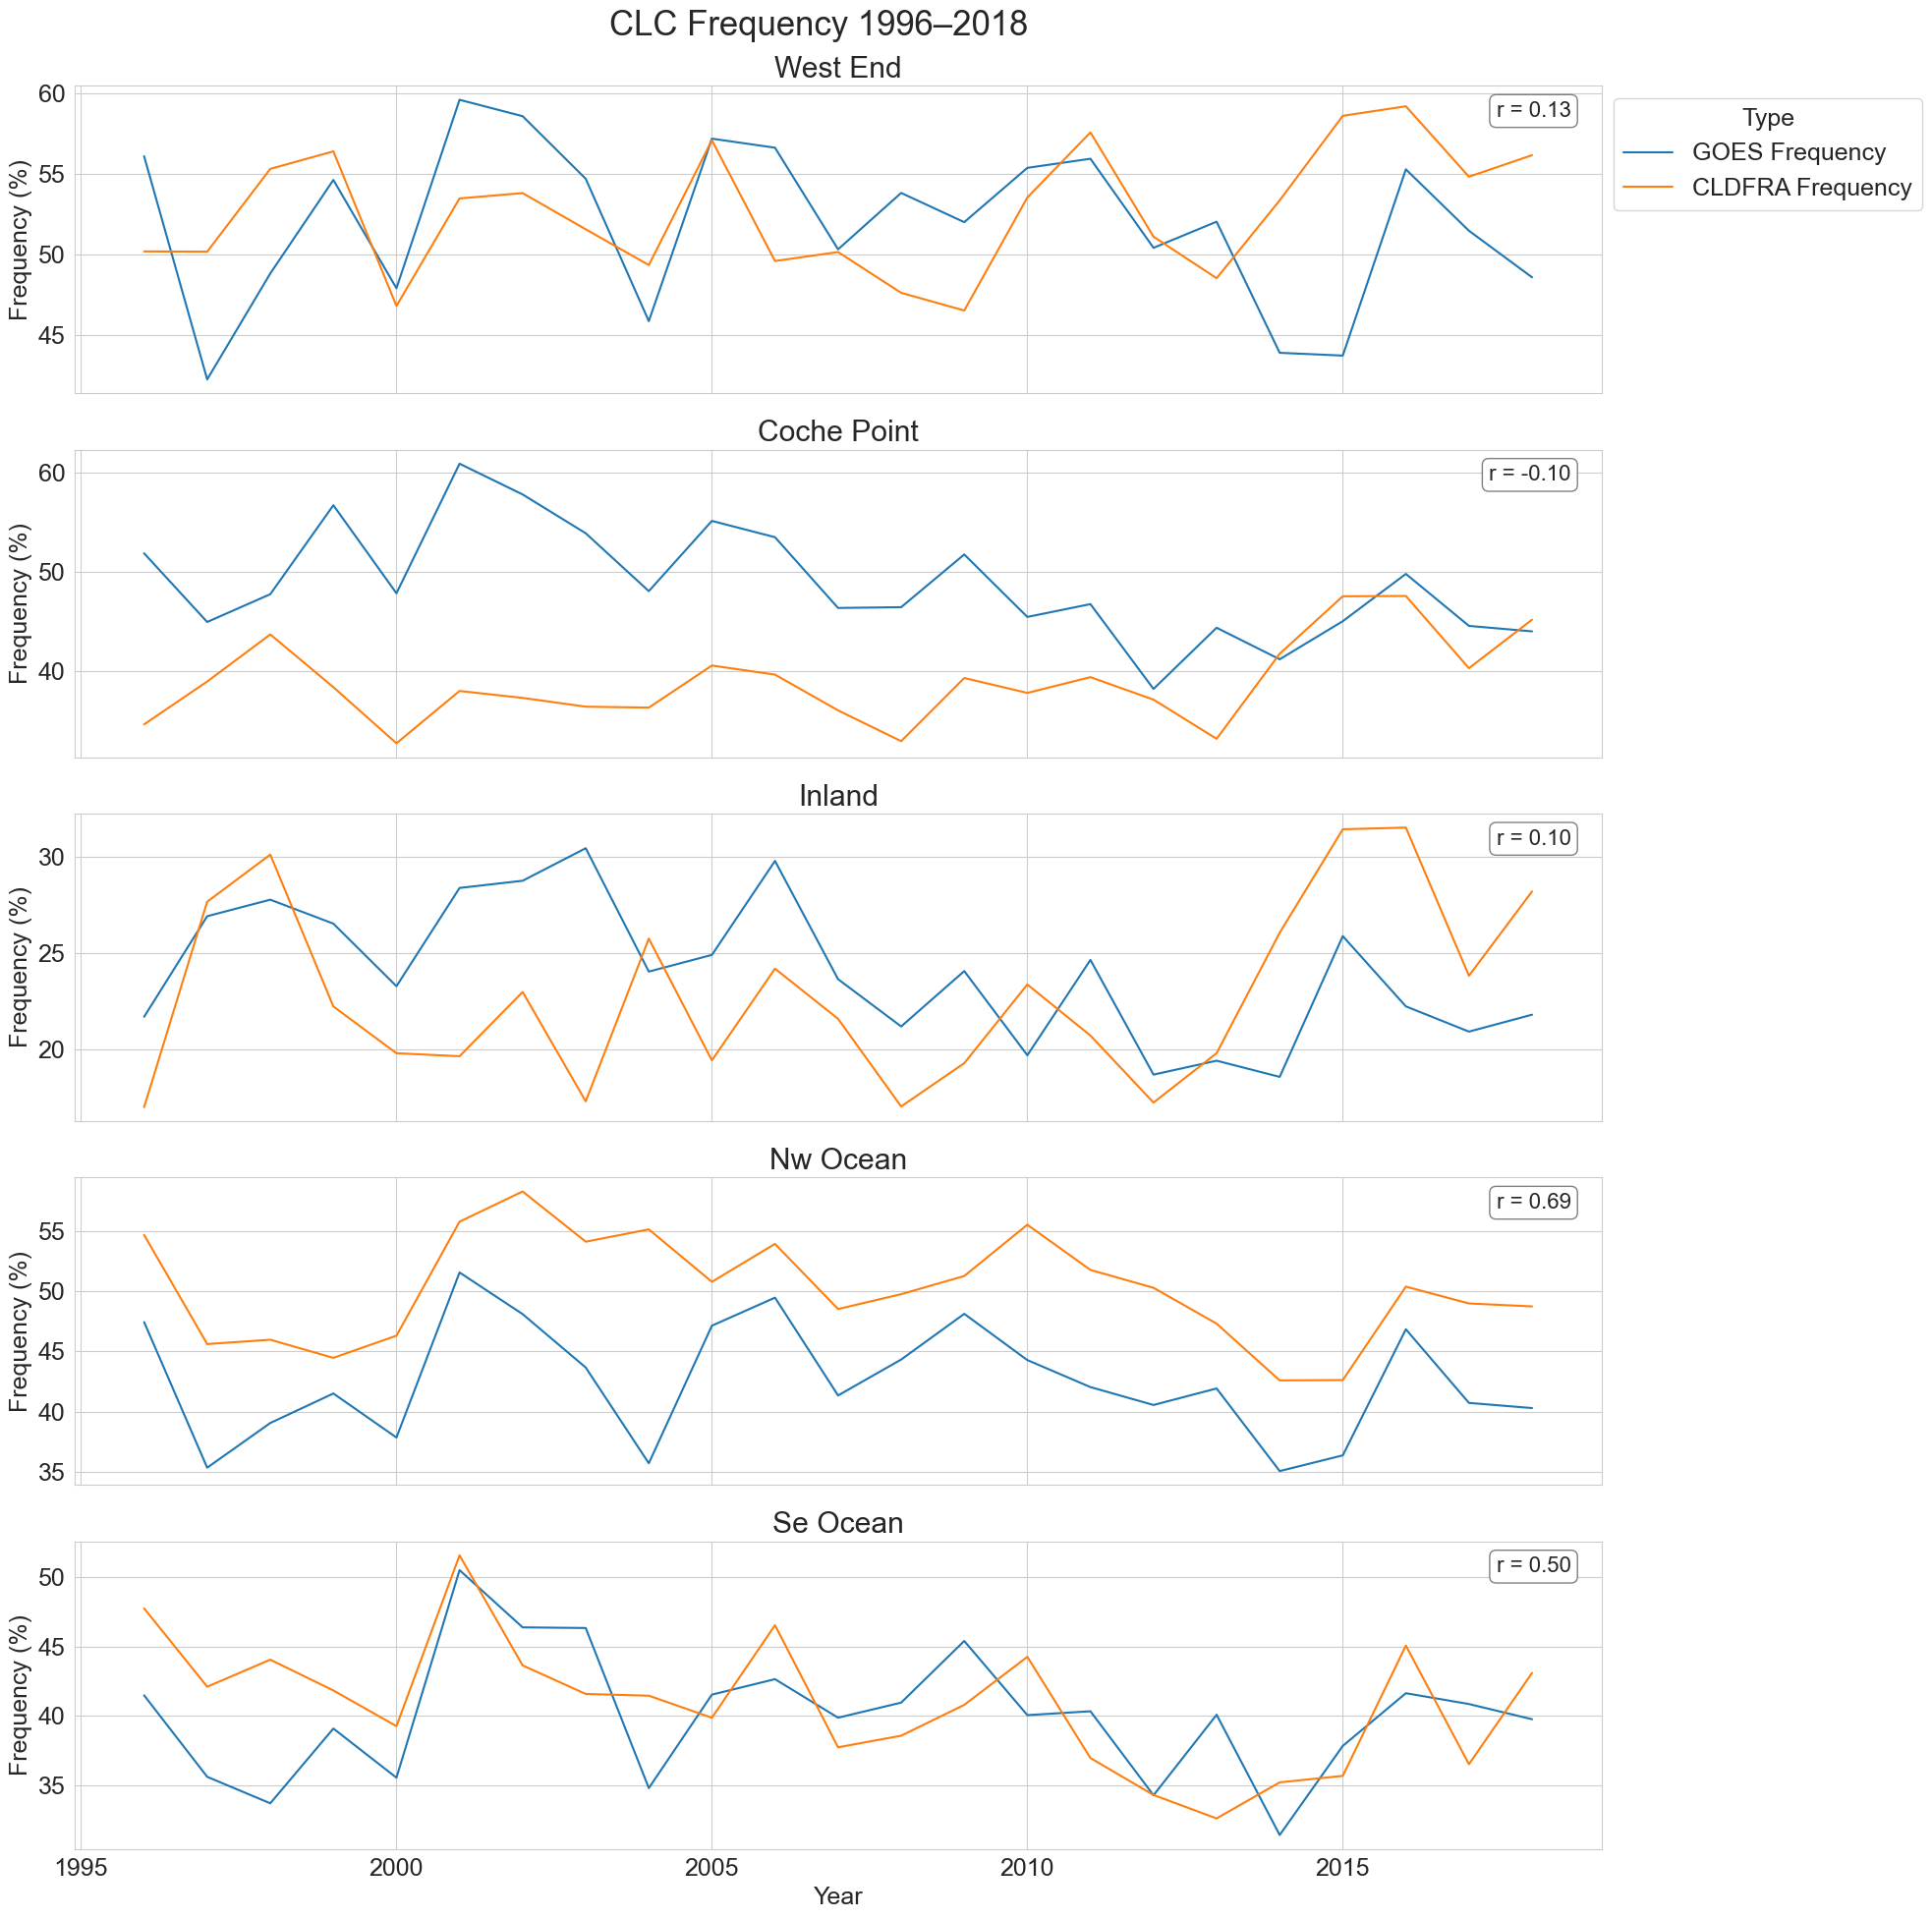

In [ ]:
# Get yearly frequencies
freq_df = get_yearly_freq(clc_ds, site_df)

# Get unique sites
sites = freq_df['site'].unique().tolist()
n_sites = len(sites)

# Plot
fig, axes = plt.subplots(nrows=n_sites, ncols=1, figsize=(20, 4 * n_sites), sharex=True)

if n_sites == 1:
    axes = [axes]

for i, site in enumerate(sites):
    site_freq_df = freq_df.loc[freq_df['site'] == site].drop('site', axis=1)
    site_freq_df_long = site_freq_df.melt(id_vars='year', var_name='type', value_name='frequency')

    ax = axes[i]
    sns.lineplot(
        data=site_freq_df_long.loc[site_freq_df_long['type'] != 'match_freq'],
        x='year',
        y='frequency',
        hue='type',
        hue_order=['goes_freq', 'cldfra_freq'],
        ax=ax
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        custom_labels = ["GOES Frequency", "CLDFRA Frequency"]
        ax.legend(handles, custom_labels, title="Type", loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.legend().remove()

    formatted_site = site.replace("-", " ").title()
    ax.set(
        title=f'{formatted_site}',
        ylabel='Frequency (%)'
    )

    # Compute and annotate correlation
    correlation = np.corrcoef(site_freq_df['goes_freq'], site_freq_df['cldfra_freq'])[0, 1]
    ax.text(
        0.98, 0.95, f'r = {correlation:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray')
    )

# Common x-axis label
axes[-1].set_xlabel('Year')

# Layout
plt.suptitle(
    f'CLC Frequency {site_freq_df["year"].min()}–{site_freq_df["year"].max()}',
    x=0.425,  
    fontsize=25
)
plt.tight_layout()
plt.show()


## Scatter Plots

### CLC Frequency vs. Match Percent

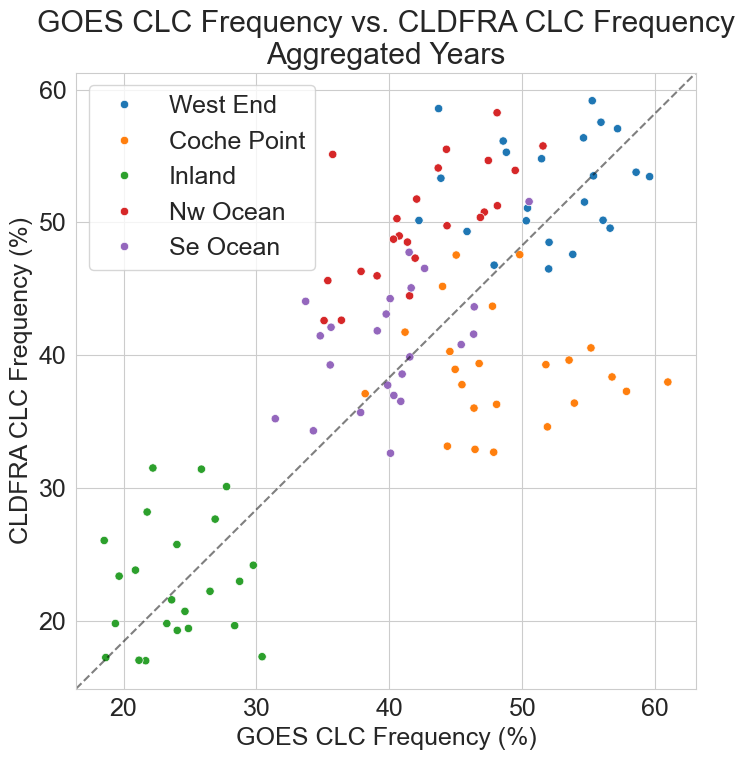

In [ ]:

# Get yearly frequencies
freq_df = get_yearly_freq(clc_ds, site_df)

# Scatter plot WRF vs. GOES CLC Frequencies by Year

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=freq_df,
                x='goes_freq',
                y='cldfra_freq',
                hue='site')
ax.set(title='GOES CLC Frequency vs. CLDFRA CLC Frequency\nAggregated Years',
       xlabel='GOES CLC Frequency (%)',
       ylabel='CLDFRA CLC Frequency (%)')

# Add diagonal line
ax.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5, transform=ax.transAxes)

# Modify legend labels
labels = freq_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]
# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, formatted_labels, title='')
plt.show()


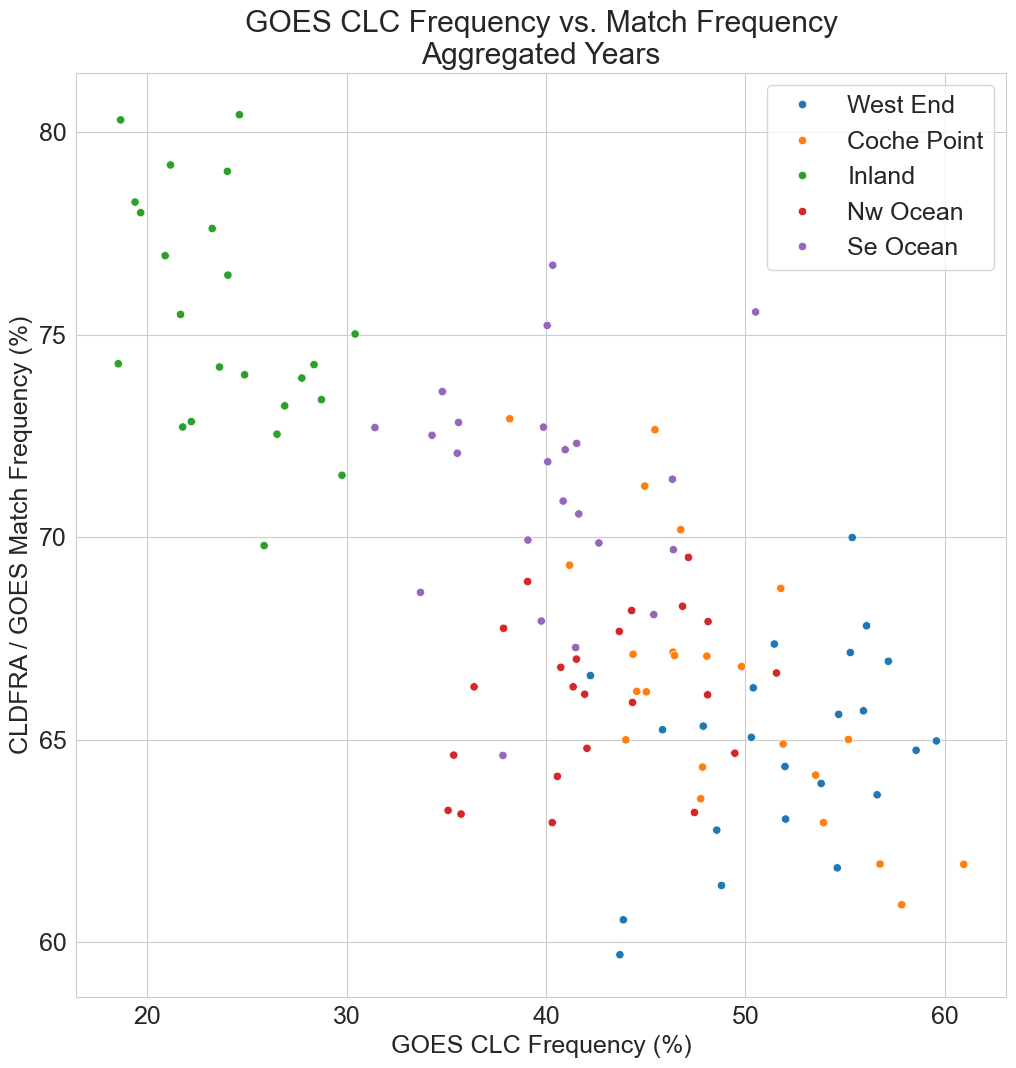

In [ ]:
# Scatter plot of Match % vs. GOES frequency
fig, ax = plt.subplots(figsize=(12,12))
sns.scatterplot(data=freq_df,
                x='goes_freq',
                y='match_freq',
                hue='site')
ax.set(title='GOES CLC Frequency vs. Match Frequency\nAggregated Years',
       xlabel='GOES CLC Frequency (%)',
       ylabel='CLDFRA / GOES Match Frequency (%)')

# Modify legend labels
labels = freq_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]

# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, formatted_labels, title='')
plt.show()


### CLC Frequency vs. WRF Frequency - Monthly Scatterplot

In [ ]:
# Aggregate by year/month
month_ds = clc_ds.groupby(['time.year', 'time.month']).sum()
total_counts = clc_ds.groupby(['time.year', 'time.month']).count()
month_ds = month_ds / total_counts * 100  # Get cloudy % per month
freq_df = pd.DataFrame()

for name in site_df['site'].tolist():
    # Subset to specific region of interest
    site_coords = site_df.loc[site_df['site'] == name]
    roi_ds = month_ds.sel(lat=slice(site_coords['lat_min'].values[0], site_coords['lat_max'].values[0]), lon=slice(site_coords['lon_min'].values[0], site_coords['lon_max'].values[0]))

    # Average over the ROI
    roi_df_mean = roi_ds.mean(dim=['lat', 'lon']).to_dataframe().reset_index()

    roi_df_mean['site'] = name

    # Join together with all sites
    freq_df = pd.concat([freq_df, roi_df_mean])
    
freq_df = freq_df.reset_index(drop=True)
freq_df = freq_df[['site', 'year', 'month', 'goes_binary', 'cldfra_binary']].rename({'goes_binary' : 'goes_freq', 'cldfra_binary' : 'cldfra_freq'}, axis=1)

In [ ]:
# Compute correlation stratified by 'category'
correlations = freq_df.groupby("site").apply(lambda g: g["goes_freq"].corr(g["cldfra_freq"]))
print(correlations)

site
coche-point    0.563320
inland         0.573541
nw-ocean       0.790981
se-ocean       0.699700
west-end       0.707192
dtype: float64


/var/folders/77/txzkwfd92_q42s0qflv4nbh00000gn/T/ipykernel_9172/1503262397.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = freq_df.groupby("site").apply(lambda g: g["goes_freq"].corr(g["cldfra_freq"]))


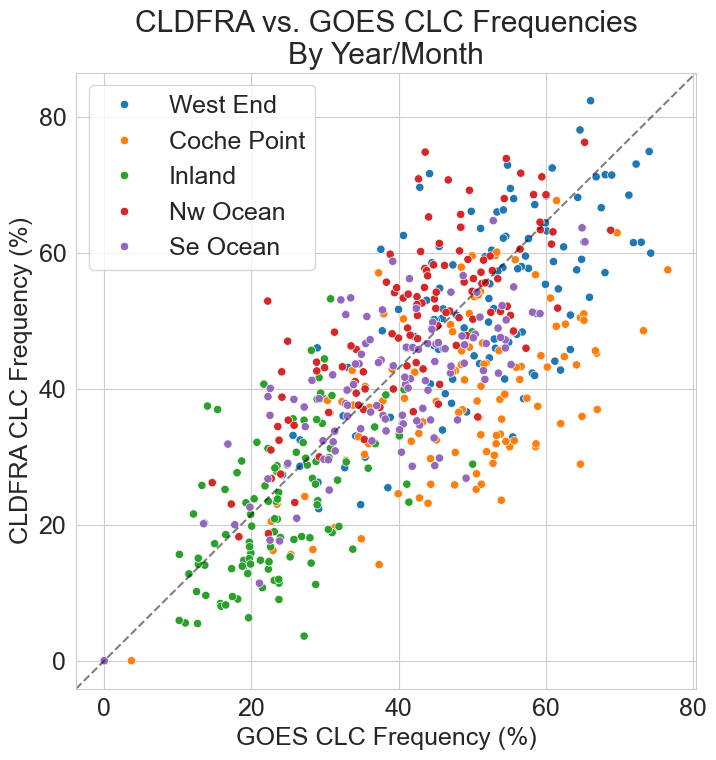

In [ ]:
# Scatterplot of WRF vs. Goes Frequencies by year/month
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(data=freq_df,
                x='goes_freq',
                y='cldfra_freq',
                hue='site')
ax.set(title='CLDFRA vs. GOES CLC Frequencies\nBy Year/Month',
       xlabel='GOES CLC Frequency (%)',
       ylabel='CLDFRA CLC Frequency (%)')
ax.legend(title='')
ticks = list(range(0,100,20))
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Add diagonal line
ax.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5, transform=ax.transAxes)

# Modify legend labels
labels = freq_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]
# Customize legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, formatted_labels, title='')
plt.show()

# Standardized Comparisons

### Trend Comparison

In [ ]:
# Group to month/year observations
ds_gp = clc_ds.groupby(['time.year', 'time.month']).sum(dim='time')
total_count = clc_ds.groupby(['time.year', 'time.month']).count(dim='time')
ds_gp = ds_gp / total_count * 100

# Average over entire study area
ds_gp = ds_gp.groupby(['year', 'month']).mean(dim=['lat', 'lon'])
df_gp = ds_gp[['goes_binary', 'cldfra_binary']].to_dataframe().reset_index()
df_gp = df_gp.rename({'goes_binary': 'goes-freq', 'cldfra_binary' : 'cldfra-freq'}, axis=1)

print(df_gp.isna().sum())  # Very few na values
df_gp.dropna(inplace=True)

year           0
month          0
goes-freq      0
cldfra-freq    0
dtype: int64


In [ ]:
# Standardize the data
scaler = StandardScaler()
df_gp['goes-std'] = scaler.fit_transform(df_gp[['goes-freq']])
df_gp['cldfra-std'] = scaler.fit_transform(df_gp[['cldfra-freq']])

In [ ]:
stats_df = pd.DataFrame()

# Overall statistics
corr = np.corrcoef(df_gp['goes-std'], df_gp['cldfra-std'])[0, 1]

bias = np.mean((df_gp['cldfra-std'] - df_gp['goes-std']))
rmse = np.sqrt(np.mean((df_gp['cldfra-std'] - df_gp['goes-std'])**2))

stat_dict = {
    'site' : 'Overall',
    'correlation' : round(corr, 2),
    'bias' : round(bias, 2),
    'rmse' : round(rmse, 2)
    }
site_stats = pd.DataFrame([stat_dict])
stats_df = pd.concat([stats_df, site_stats], axis=0)



In [ ]:
# AOI Statistics
for site in freq_df['site'].unique():
    site_stats_df = freq_df.loc[freq_df['site'] == site]
    corr = np.corrcoef(site_stats_df['goes_freq'], site_stats_df['cldfra_freq'])[0, 1]
    
    bias = np.mean((site_stats_df['cldfra_freq'] - site_stats_df['goes_freq']))
    rmse = np.sqrt(np.mean((site_stats_df['cldfra_freq'] - site_stats_df['goes_freq'])**2))

    stat_dict = {
        'site' : site,
        'correlation' : round(corr, 2),
        'bias' : round(bias, 2),
        'rmse' : round(rmse, 2)
        }
    site_stats = pd.DataFrame([stat_dict])
    stats_df = pd.concat([stats_df, site_stats], axis=0)



stats_df.T

,0,0,0,0,0,0
site,Overall,west-end,coche-point,inland,nw-ocean,se-ocean
correlation,0.77,0.71,0.56,0.57,0.79,0.7
bias,0.0,0.67,-9.88,-1.23,7.51,1.0
rmse,0.68,10.33,14.94,9.11,11.18,8.51


MSE: 0.458


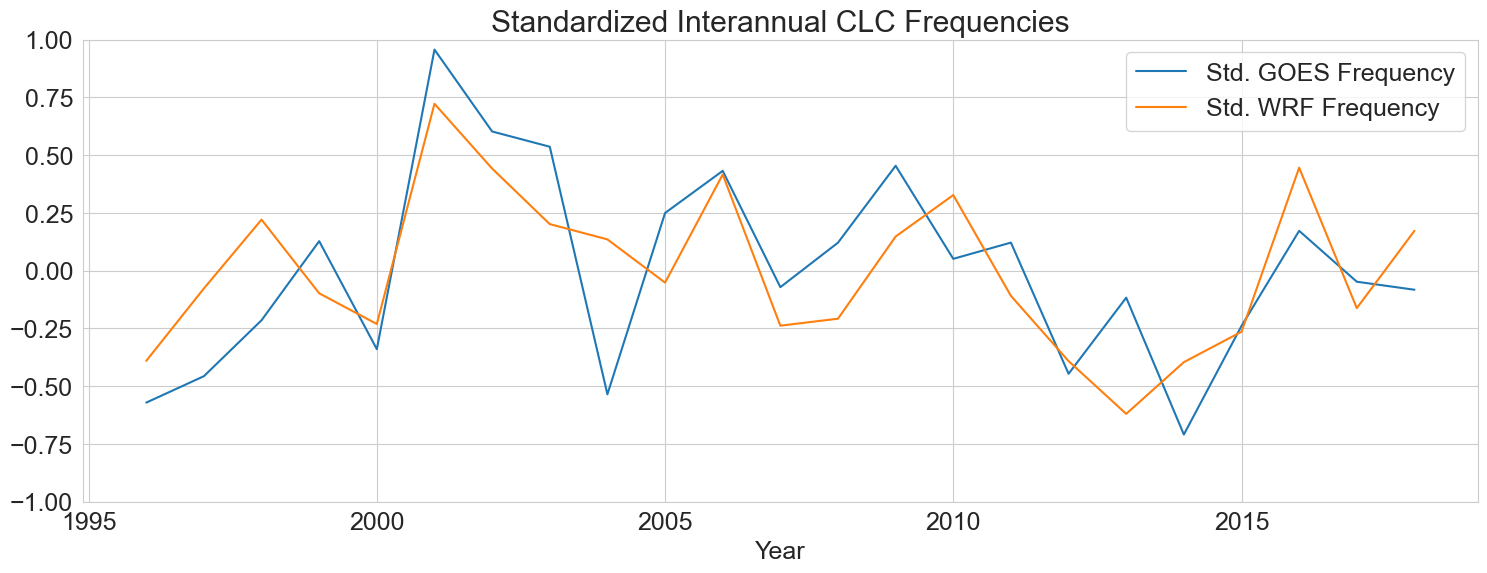

In [ ]:
# Calculate similarities
mse = mean_squared_error(df_gp['goes-std'], df_gp['cldfra-std'])
print("MSE:", round(mse,3))

# Plot the data
fig, ax = plt.subplots(figsize=(18,6))
sns.lineplot(data=df_gp,
             x='year',
             y='goes-std',
             label='Std. GOES Frequency',
             errorbar=None)
sns.lineplot(data=df_gp,
             x='year',
             y='cldfra-std',
             label='Std. WRF Frequency',
             errorbar=None)
ax.set(title='Standardized Interannual CLC Frequencies',
       xlabel='Year',
       ylabel='')
ax.set_ylim(-1,1)
plt.show()

## CLDFRA Threshold Check
Look for a relationship between Albedo and the WRF variables wiht the goal of identifying a cloud/no cloud threshold. We use an albedo threshold of 8.5%, provided by Rachel Clemesha. We know that the WRF predictions don't necessarily quite line up with reality, but I'm hoping to find some signal. 


__Observations:__ There aren't any clear relationships from the distributions, so instead we'll use regions of interest to find a threshold. 

In [ ]:
# This takes over 25 minutes to run, with no clear relationships
run = False

if run == True: 
       clc_df = clc_ds.to_dataframe().reset_index()
       clc_df['goes_binary'] = clc_df['goes'].apply(lambda x: 1 if x > 8.5 else 0)
       # Nonzero Histograms

       # GOES albedo
       fig, ax = plt.subplots(figsize=(12, 6))
       sns.histplot(clc_df.loc[clc_df['goes']!=0],
              x='goes',
              stat='percent')
       ax.set_xticks(np.arange(0,110,10))
       ax.set(title='Distribution of GOES Albedo\nNonzero Values',
              xlabel='GOES Albedo (%)')
       plt.show()

       # CLDFRA
       fig, ax = plt.subplots(figsize=(12, 6))
       sns.histplot(clc_df.loc[clc_df['cldfra']!=0],
              x='cldfra',
              hue='goes_binary',
              common_norm=False,
              stat='percent')
       ax.set(title='Distribution of CLDFRA\nNonzero Values',
              xlabel='CLDFRA')
       plt.show()

       fig, ax = plt.subplots(figsize=(12, 6))
       sns.scatterplot(data=clc_df,
                     x='goes',
                     y='cldfra',
                     alpha=0.01)
       ax.set(title='GOES Albedo vs. CLDFRA')
       plt.show()

# Save out processed clc_ds

In [ ]:
run = False
if run == True: 
    out_fpath = root_dir / 'data' / 'geospatial' / 'goes-cldalbedo-1km' / 'clc-1km-processed.nc'
    clc_ds.to_netcdf(out_fpath)
    print("Saved out:", out_fpath)